In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — LOAD ROUND 5 DATA
# ════════════════════════════════════════════════════════════════════════════

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROUND = 5
DAYS = [2, 3, 4]

DATA_DIR = Path("Data/round5")

ALGO_PRODUCTS = [
    # Galaxy Sounds Recorders
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",

    # Vertical Sleeping Pods
    "SLEEP_POD_SUEDE",
    "SLEEP_POD_LAMB_WOOL",
    "SLEEP_POD_POLYESTER",
    "SLEEP_POD_NYLON",
    "SLEEP_POD_COTTON",

    # Organic Microchips
    "MICROCHIP_CIRCLE",
    "MICROCHIP_OVAL",
    "MICROCHIP_SQUARE",
    "MICROCHIP_RECTANGLE",
    "MICROCHIP_TRIANGLE",

    # Purification Pebbles
    "PEBBLES_XS",
    "PEBBLES_S",
    "PEBBLES_M",
    "PEBBLES_L",
    "PEBBLES_XL",

    # Domestic Robots
    "ROBOT_VACUUMING",
    "ROBOT_MOPPING",
    "ROBOT_DISHES",
    "ROBOT_LAUNDRY",
    "ROBOT_IRONING",

    # UV-Visors
    "UV_VISOR_YELLOW",
    "UV_VISOR_AMBER",
    "UV_VISOR_ORANGE",
    "UV_VISOR_RED",
    "UV_VISOR_MAGENTA",

    # Instant Translators
    "TRANSLATOR_SPACE_GRAY",
    "TRANSLATOR_ASTRO_BLACK",
    "TRANSLATOR_ECLIPSE_CHARCOAL",
    "TRANSLATOR_GRAPHITE_MIST",
    "TRANSLATOR_VOID_BLUE",

    # Construction Panels
    "PANEL_1X2",
    "PANEL_2X2",
    "PANEL_1X4",
    "PANEL_2X4",
    "PANEL_4X4",

    # Liquid Breath Oxygen Shakes
    "OXYGEN_SHAKE_MORNING_BREATH",
    "OXYGEN_SHAKE_EVENING_BREATH",
    "OXYGEN_SHAKE_MINT",
    "OXYGEN_SHAKE_CHOCOLATE",
    "OXYGEN_SHAKE_GARLIC",

    # Protein Snack Packs
    "SNACKPACK_CHOCOLATE",
    "SNACKPACK_VANILLA",
    "SNACKPACK_PISTACHIO",
    "SNACKPACK_STRAWBERRY",
    "SNACKPACK_RASPBERRY",
]

POSITION_LIMITS = {product: 10 for product in ALGO_PRODUCTS}

prices_parts = []
trades_parts = []

for day in DAYS:
    price_path = DATA_DIR / f"prices_round_{ROUND}_day_{day}.csv"
    trade_path = DATA_DIR / f"trades_round_{ROUND}_day_{day}.csv"

    p = pd.read_csv(price_path, sep=";")
    t = pd.read_csv(trade_path, sep=";")

    p["file_day"] = day
    t["file_day"] = day

    prices_parts.append(p)
    trades_parts.append(t)

prices = pd.concat(prices_parts, ignore_index=True)
trades = pd.concat(trades_parts, ignore_index=True)

# Standardise trade product column name.
if "symbol" in trades.columns and "product" not in trades.columns:
    trades = trades.rename(columns={"symbol": "product"})

# Keep only valid Round 5 algorithmic products.
prices = prices[prices["product"].isin(ALGO_PRODUCTS)].copy()
trades = trades[trades["product"].isin(ALGO_PRODUCTS)].copy()

# Useful global time index across days.
# Assumes timestamp resets each day.
min_day = min(DAYS)
prices["global_ts"] = (prices["file_day"] - min_day) * 1_000_000 + prices["timestamp"]
trades["global_ts"] = (trades["file_day"] - min_day) * 1_000_000 + trades["timestamp"]

prices = prices.sort_values(["product", "global_ts"]).reset_index(drop=True)
trades = trades.sort_values(["product", "global_ts"]).reset_index(drop=True)

# Basic sanity checks.
price_products = sorted(prices["product"].unique())
trade_products = sorted(trades["product"].unique())

missing_in_prices = sorted(set(ALGO_PRODUCTS) - set(price_products))
missing_in_trades = sorted(set(ALGO_PRODUCTS) - set(trade_products))

print("prices shape:", prices.shape)
print("trades shape:", trades.shape)
print()
print("Price products:", price_products)
print("Trade products:", trade_products)
print()
print("Missing in prices:", missing_in_prices)
print("Missing in trades:", missing_in_trades)
print()
print("Price days:", sorted(prices["file_day"].unique()))
print("Trade days:", sorted(trades["file_day"].unique()))
print()
print("Position limits:", POSITION_LIMITS)

display(prices.head())
display(trades.head())

prices shape: (1500000, 19)
trades shape: (35385, 9)

Price products: ['GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_FLAMES', 'GALAXY_SOUNDS_SOLAR_WINDS', 'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE', 'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_GARLIC', 'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_MORNING_BREATH', 'PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4', 'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS', 'ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING', 'SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE', 'SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA', 'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_SPACE_GRAY'

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,file_day,global_ts
0,2,0,GALAXY_SOUNDS_BLACK_HOLES,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0,2,0
1,2,100,GALAXY_SOUNDS_BLACK_HOLES,10001,18,10000.0,25.0,NaN,NaN,10014,18,10016.0,25.0,NaN,NaN,10007.5,0.0,2,100
2,2,200,GALAXY_SOUNDS_BLACK_HOLES,9996,19,9995.0,31.0,NaN,NaN,10009,19,10011.0,31.0,NaN,NaN,10002.5,0.0,2,200
3,2,300,GALAXY_SOUNDS_BLACK_HOLES,9994,25,9993.0,33.0,NaN,NaN,10007,25,10009.0,33.0,NaN,NaN,10000.5,0.0,2,300
4,2,400,GALAXY_SOUNDS_BLACK_HOLES,9999,14,9997.0,32.0,NaN,NaN,10012,14,10013.0,32.0,NaN,NaN,10005.5,0.0,2,400


,timestamp,buyer,seller,product,currency,price,quantity,file_day,global_ts
0,1700,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9969.0,4,2,1700
1,14500,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9749.0,1,2,14500
2,15100,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9764.0,2,2,15100
3,26500,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9656.0,4,2,26500
4,36400,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9675.0,4,2,36400


Robot price shape: (150000, 22)
Robot trade shape: (3665, 9)

Robot products in prices: ['ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING']
Robot products in trades: ['ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING']


,product,rows,days,mean_mid,std_mid,min_mid,max_mid,mean_spread,median_spread,mode_spread,mean_bid_vol_1,mean_ask_vol_1,mean_depth_1,mean_imbalance_1,std_imbalance_1,last_pnl_seen,public_trades,public_trade_volume,mean_trade_size,mean_trade_price,std_trade_price
0,ROBOT_DISHES,30000,3,10018.314900,556.639109,8855.0,11400.0,7.350267,7.0,8,7.624333,7.609433,15.233767,0.000441,0.226380,0.0,733,1805,2.462483,10021.672578,550.732867
1,ROBOT_IRONING,30000,3,8701.570267,771.029728,7458.5,10102.0,6.392933,6.0,6,8.352800,8.350133,16.702933,-0.000082,0.071307,0.0,733,1805,2.462483,8674.081855,759.792285
2,ROBOT_LAUNDRY,30000,3,9822.761700,614.322320,8553.0,10859.0,7.165067,7.0,7,8.015533,8.079600,16.095133,-0.003015,0.296978,0.0,733,1805,2.462483,9800.845839,612.435646
3,ROBOT_MOPPING,30000,3,11100.213233,767.160739,9593.0,12389.5,7.970667,8.0,8,7.061267,7.068067,14.129333,-0.001049,0.216620,0.0,733,1805,2.462483,11134.156889,777.714909
4,ROBOT_VACUUMING,30000,3,9166.775783,535.258653,8242.5,10303.0,6.753300,7.0,7,8.604267,8.541200,17.145467,0.002987,0.284597,0.0,733,1805,2.462483,9143.911323,528.437266


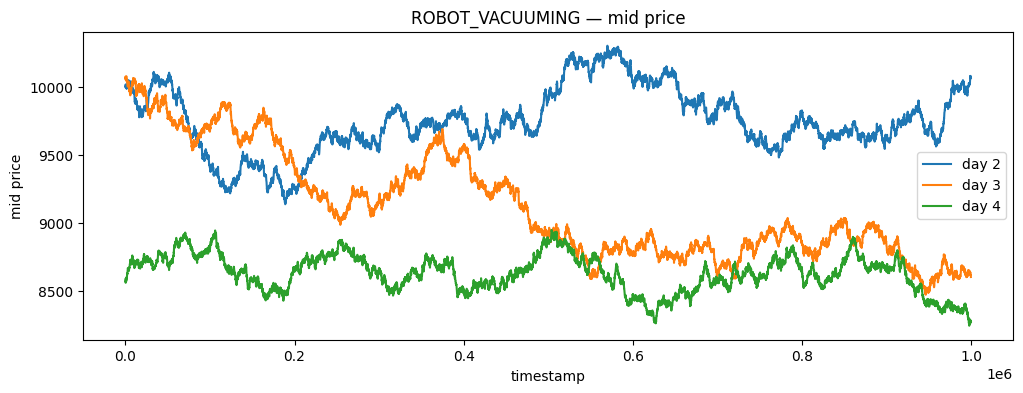

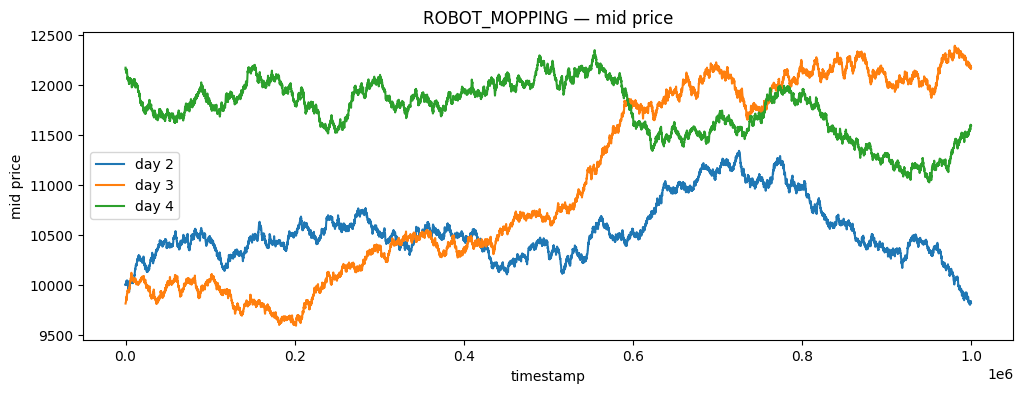

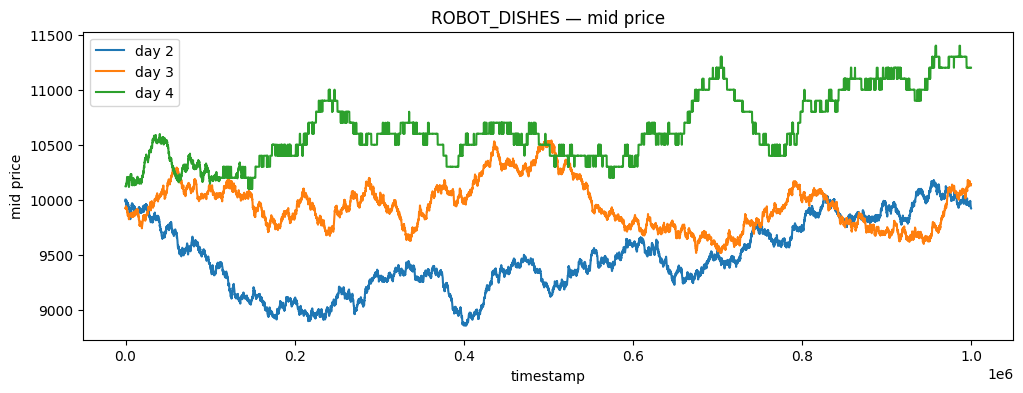

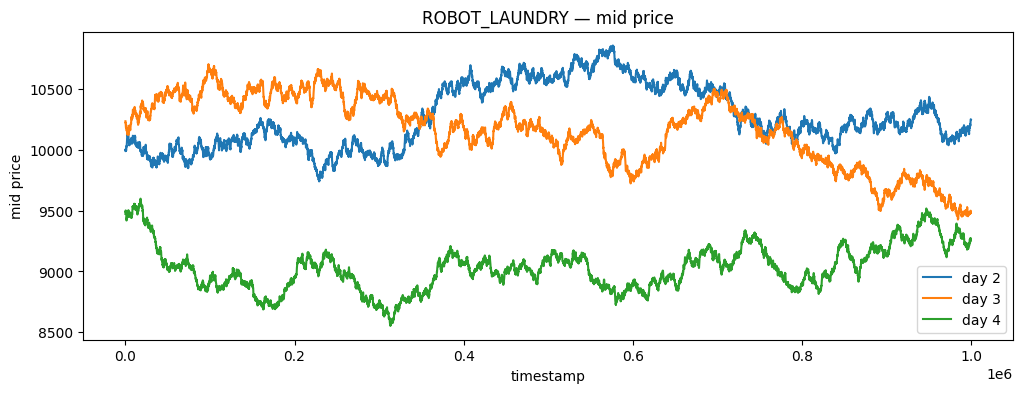

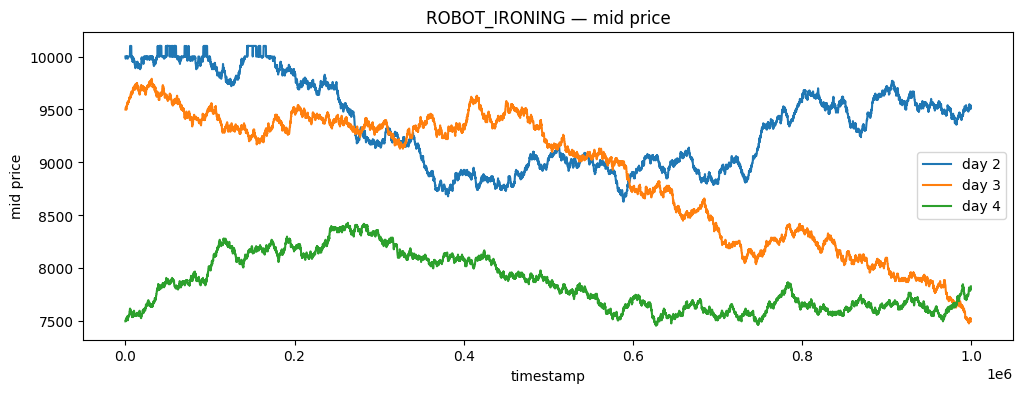

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — DOMESTIC ROBOTS SUBSET + MARKET FINGERPRINT
# ════════════════════════════════════════════════════════════════════════════

ROBOT_PRODUCTS = [
    "ROBOT_VACUUMING",
    "ROBOT_MOPPING",
    "ROBOT_DISHES",
    "ROBOT_LAUNDRY",
    "ROBOT_IRONING",
]

robots_prices = prices[prices["product"].isin(ROBOT_PRODUCTS)].copy()
robots_trades = trades[trades["product"].isin(ROBOT_PRODUCTS)].copy()

# Ensure mid price exists.
if "mid_price" not in robots_prices.columns:
    robots_prices["mid_price"] = (
        robots_prices["bid_price_1"] + robots_prices["ask_price_1"]
    ) / 2

robots_prices["spread"] = robots_prices["ask_price_1"] - robots_prices["bid_price_1"]

robots_prices["depth_1"] = (
    robots_prices["bid_volume_1"].fillna(0)
    + robots_prices["ask_volume_1"].fillna(0)
)

robots_prices["imbalance_1"] = (
    robots_prices["bid_volume_1"].fillna(0)
    - robots_prices["ask_volume_1"].fillna(0)
) / robots_prices["depth_1"].replace(0, np.nan)

print("Robot price shape:", robots_prices.shape)
print("Robot trade shape:", robots_trades.shape)
print()
print("Robot products in prices:", sorted(robots_prices["product"].unique()))
print("Robot products in trades:", sorted(robots_trades["product"].unique()))

price_agg = {
    "rows": ("timestamp", "count"),
    "days": ("file_day", "nunique"),
    "mean_mid": ("mid_price", "mean"),
    "std_mid": ("mid_price", "std"),
    "min_mid": ("mid_price", "min"),
    "max_mid": ("mid_price", "max"),
    "mean_spread": ("spread", "mean"),
    "median_spread": ("spread", "median"),
    "mode_spread": ("spread", lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan),
    "mean_bid_vol_1": ("bid_volume_1", "mean"),
    "mean_ask_vol_1": ("ask_volume_1", "mean"),
    "mean_depth_1": ("depth_1", "mean"),
    "mean_imbalance_1": ("imbalance_1", "mean"),
    "std_imbalance_1": ("imbalance_1", "std"),
}

if "profit_and_loss" in robots_prices.columns:
    price_agg["last_pnl_seen"] = ("profit_and_loss", "last")

price_fingerprint = (
    robots_prices
    .groupby("product")
    .agg(**price_agg)
    .reset_index()
)

if len(robots_trades):
    trade_agg = {
        "public_trades": ("timestamp", "count"),
    }

    if "quantity" in robots_trades.columns:
        trade_agg["public_trade_volume"] = ("quantity", "sum")
        trade_agg["mean_trade_size"] = ("quantity", "mean")

    if "price" in robots_trades.columns:
        trade_agg["mean_trade_price"] = ("price", "mean")
        trade_agg["std_trade_price"] = ("price", "std")

    trade_fingerprint = (
        robots_trades
        .groupby("product")
        .agg(**trade_agg)
        .reset_index()
    )

    fingerprint = price_fingerprint.merge(
        trade_fingerprint,
        on="product",
        how="left"
    )
else:
    fingerprint = price_fingerprint.copy()

display(fingerprint)

# Quick visual check: mid prices by product/day.
for product in ROBOT_PRODUCTS:
    tmp = robots_prices[robots_prices["product"] == product]

    plt.figure(figsize=(12, 4))
    for day, g in tmp.groupby("file_day"):
        plt.plot(g["timestamp"], g["mid_price"], label=f"day {day}")

    plt.title(f"{product} — mid price")
    plt.xlabel("timestamp")
    plt.ylabel("mid price")
    plt.legend()
    plt.show()

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — WIDE TABLES + RELATIONSHIP SCAN
# ════════════════════════════════════════════════════════════════════════════

def make_wide(df, value_col):
    return (
        df.pivot_table(
            index=["file_day", "timestamp"],
            columns="product",
            values=value_col,
            aggfunc="last",
        )
        .sort_index()
    )

mid = make_wide(robots_prices, "mid_price")
bid = make_wide(robots_prices, "bid_price_1")
ask = make_wide(robots_prices, "ask_price_1")
spread = make_wide(robots_prices, "spread")
bidv1 = make_wide(robots_prices, "bid_volume_1")
askv1 = make_wide(robots_prices, "ask_volume_1")
imbalance = make_wide(robots_prices, "imbalance_1")

rets_1 = mid.groupby(level="file_day").diff(1)
rets_5 = mid.groupby(level="file_day").diff(5)
rets_20 = mid.groupby(level="file_day").diff(20)

print("Mid-price correlation:")
display(mid.corr())

print("1-tick return correlation:")
display(rets_1.corr())

print("5-tick return correlation:")
display(rets_5.corr())

print("20-tick return correlation:")
display(rets_20.corr())

# Lead/lag scan:
# lead_product return at t-lag versus target_product return at t.
lag_rows = []

LAGS = [1, 2, 5, 10, 20, 50, 100, 250, 500, 1000]

for lead in ROBOT_PRODUCTS:
    for target in ROBOT_PRODUCTS:
        if lead == target:
            continue

        for lag in LAGS:
            day_corrs = []

            for day in sorted(mid.index.get_level_values("file_day").unique()):
                lead_ret = rets_1.xs(day, level="file_day")[lead]
                target_ret = rets_1.xs(day, level="file_day")[target]

                corr = lead_ret.shift(lag).corr(target_ret)
                day_corrs.append(corr)

            lag_rows.append({
                "lead_product": lead,
                "target_product": target,
                "lag": lag,
                "mean_lag_corr": np.nanmean(day_corrs),
                "min_day_corr": np.nanmin(day_corrs),
                "max_day_corr": np.nanmax(day_corrs),
                "day_corrs": day_corrs,
            })

lag_scan = pd.DataFrame(lag_rows)
lag_scan["abs_mean_lag_corr"] = lag_scan["mean_lag_corr"].abs()

lag_scan = lag_scan.sort_values(
    "abs_mean_lag_corr",
    ascending=False,
).reset_index(drop=True)

display(lag_scan.head(75))

# Spread/depth stability board.
spread_board = (
    spread
    .stack()
    .rename("spread")
    .reset_index()
    .rename(columns={"product": "product"})
    .groupby("product")
    .agg(
        mean_spread=("spread", "mean"),
        median_spread=("spread", "median"),
        min_spread=("spread", "min"),
        max_spread=("spread", "max"),
        spread_std=("spread", "std"),
    )
    .reset_index()
)

depth_board = (
    (bidv1 + askv1)
    .stack()
    .rename("depth_1")
    .reset_index()
    .groupby("product")
    .agg(
        mean_depth_1=("depth_1", "mean"),
        median_depth_1=("depth_1", "median"),
        min_depth_1=("depth_1", "min"),
        max_depth_1=("depth_1", "max"),
    )
    .reset_index()
)

display(spread_board.merge(depth_board, on="product", how="left"))

Mid-price correlation:


product,ROBOT_DISHES,ROBOT_IRONING,ROBOT_LAUNDRY,ROBOT_MOPPING,ROBOT_VACUUMING
product,,,,,
ROBOT_DISHES,1.000000,-0.648398,-0.723315,0.439142,-0.686489
ROBOT_IRONING,-0.648398,1.000000,0.737141,-0.815181,0.784240
ROBOT_LAUNDRY,-0.723315,0.737141,1.000000,-0.713475,0.787417
ROBOT_MOPPING,0.439142,-0.815181,-0.713475,1.000000,-0.785996
ROBOT_VACUUMING,-0.686489,0.784240,0.787417,-0.785996,1.000000


1-tick return correlation:


product,ROBOT_DISHES,ROBOT_IRONING,ROBOT_LAUNDRY,ROBOT_MOPPING,ROBOT_VACUUMING
product,,,,,
ROBOT_DISHES,1.000000,0.000406,0.001251,-0.006345,0.005338
ROBOT_IRONING,0.000406,1.000000,-0.008210,-0.000241,0.012508
ROBOT_LAUNDRY,0.001251,-0.008210,1.000000,-0.009395,-0.001948
ROBOT_MOPPING,-0.006345,-0.000241,-0.009395,1.000000,-0.003857
ROBOT_VACUUMING,0.005338,0.012508,-0.001948,-0.003857,1.000000


5-tick return correlation:


product,ROBOT_DISHES,ROBOT_IRONING,ROBOT_LAUNDRY,ROBOT_MOPPING,ROBOT_VACUUMING
product,,,,,
ROBOT_DISHES,1.000000,-0.001049,-0.005224,-0.019283,0.001048
ROBOT_IRONING,-0.001049,1.000000,-0.015330,0.012672,0.019086
ROBOT_LAUNDRY,-0.005224,-0.015330,1.000000,-0.005724,-0.006145
ROBOT_MOPPING,-0.019283,0.012672,-0.005724,1.000000,-0.019219
ROBOT_VACUUMING,0.001048,0.019086,-0.006145,-0.019219,1.000000


20-tick return correlation:


product,ROBOT_DISHES,ROBOT_IRONING,ROBOT_LAUNDRY,ROBOT_MOPPING,ROBOT_VACUUMING
product,,,,,
ROBOT_DISHES,1.000000,-0.009527,-0.020168,-0.015593,0.006839
ROBOT_IRONING,-0.009527,1.000000,-0.010884,0.045350,0.027682
ROBOT_LAUNDRY,-0.020168,-0.010884,1.000000,-0.012037,0.026611
ROBOT_MOPPING,-0.015593,0.045350,-0.012037,1.000000,-0.039920
ROBOT_VACUUMING,0.006839,0.027682,0.026611,-0.039920,1.000000


,lead_product,target_product,lag,mean_lag_corr,min_day_corr,max_day_corr,day_corrs,abs_mean_lag_corr
0,ROBOT_IRONING,ROBOT_MOPPING,500,-0.016498,-0.037281,0.001246,"[-0.013457673542153338, -0.037280960403168265,...",0.016498
1,ROBOT_MOPPING,ROBOT_IRONING,500,-0.015703,-0.024366,-0.003526,"[-0.003525674258257612, -0.019217487328577552,...",0.015703
2,ROBOT_LAUNDRY,ROBOT_IRONING,500,0.014354,0.008219,0.025851,"[0.008218763770746975, 0.025850894892093298, 0...",0.014354
3,ROBOT_IRONING,ROBOT_MOPPING,1000,-0.014236,-0.018105,-0.009931,"[-0.009930964135804245, -0.014670419475845508,...",0.014236
4,ROBOT_MOPPING,ROBOT_LAUNDRY,10,-0.013708,-0.022468,-0.005160,"[-0.01349464526128434, -0.005159751357457612, ...",0.013708
5,ROBOT_DISHES,ROBOT_IRONING,50,-0.013484,-0.021589,-0.007401,"[-0.01146159390233482, -0.007400886302005908, ...",0.013484
6,ROBOT_LAUNDRY,ROBOT_MOPPING,1000,0.013474,-0.000146,0.023856,"[-0.00014620930433649384, 0.016711513566298807...",0.013474
7,ROBOT_VACUUMING,ROBOT_LAUNDRY,5,-0.012887,-0.027905,-0.004617,"[-0.027904508839326672, -0.006139403898885499,...",0.012887
8,ROBOT_MOPPING,ROBOT_IRONING,10,0.012850,0.000107,0.026103,"[0.026102568251145722, 0.012339505676281242, 0...",0.012850
9,ROBOT_MOPPING,ROBOT_VACUUMING,50,0.012137,0.009382,0.015088,"[0.015088200825293437, 0.011940464683356767, 0...",0.012137


,product,mean_spread,median_spread,min_spread,max_spread,spread_std,mean_depth_1,median_depth_1,min_depth_1,max_depth_1
0,ROBOT_DISHES,7.350267,7.0,2,8,0.854208,15.233767,14.0,6,40
1,ROBOT_IRONING,6.392933,6.0,3,8,1.037580,16.702933,14.0,6,40
2,ROBOT_LAUNDRY,7.165067,7.0,2,8,0.882711,16.095133,16.0,6,40
3,ROBOT_MOPPING,7.970667,8.0,3,9,0.984127,14.129333,14.0,6,40
4,ROBOT_VACUUMING,6.753300,7.0,2,8,0.831101,17.145467,16.0,6,40


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — GENERATE ROBOTICS ALPHA CANDIDATES
# ════════════════════════════════════════════════════════════════════════════

def rolling_zscore_by_day(s, window):
    """
    Rolling z-score within each day.
    Uses only data up to the current timestamp.
    """
    min_periods = max(20, window // 5)

    def _z(x):
        mu = x.rolling(window, min_periods=min_periods).mean()
        sd = x.rolling(window, min_periods=min_periods).std()
        return (x - mu) / sd.replace(0, np.nan)

    return s.groupby(level="file_day").transform(_z)


def safe_log_ratio(a, b):
    return np.log(a / b)


def generate_robot_candidates(
    mid,
    imbalance,
    products,
    windows=(50, 100, 250, 500, 1000),
    lead_lags=(1, 2, 5, 10, 20, 50, 100, 250),
    lead_windows=(100, 250, 500),
    imbalance_windows=(20, 50, 100, 250, 500),
):
    candidates = []

    # A. Own-product mean reversion.
    # Signal high => product rich => short.
    for p in products:
        for w in windows:
            sig = rolling_zscore_by_day(mid[p], w)

            candidates.append({
                "name": f"own_mr::{p}::w{w}",
                "family": "own_mr",
                "signal": sig,
                "weights": {p: 1.0},
                "description": f"{p} own rolling mean reversion, window={w}",
            })

    # B. Pair log-ratio mean reversion.
    # Signal high => a rich vs b => short a, long b.
    for a in products:
        for b in products:
            if a == b:
                continue

            raw = safe_log_ratio(mid[a], mid[b])

            for w in windows:
                sig = rolling_zscore_by_day(raw, w)

                candidates.append({
                    "name": f"pair_logratio_mr::{a}_vs_{b}::w{w}",
                    "family": "pair_logratio_mr",
                    "signal": sig,
                    "weights": {a: 1.0, b: -1.0},
                    "description": f"log({a}/{b}) rolling mean reversion, window={w}",
                })

    # C. Product versus equal basket of other robots.
    # Signal high => target rich vs basket => short target, long basket.
    for target in products:
        others = [p for p in products if p != target]
        basket = mid[others].mean(axis=1)
        raw = mid[target] - basket

        for w in windows:
            sig = rolling_zscore_by_day(raw, w)

            weights = {target: 1.0}
            for o in others:
                weights[o] = -1.0 / len(others)

            candidates.append({
                "name": f"basket_resid_mr::{target}_vs_equal_robot_basket::w{w}",
                "family": "basket_resid_mr",
                "signal": sig,
                "weights": weights,
                "description": f"{target} versus equal basket of other robots, window={w}",
            })

    # D. Lead-lag same-direction and inverse candidates.
    # Tester convention:
    # signal > entry => short positive-weight leg.
    # signal < -entry => long positive-weight leg.
    for lead in products:
        for target in products:
            if lead == target:
                continue

            for lag in lead_lags:
                lead_ret = mid[lead].groupby(level="file_day").diff(lag)

                for w in lead_windows:
                    z = rolling_zscore_by_day(lead_ret, w)

                    # Same direction:
                    # lead up => buy target.
                    # Need signal negative when lead z positive.
                    candidates.append({
                        "name": f"leadlag_same::{lead}_to_{target}::lag{lag}::w{w}",
                        "family": "leadlag_same",
                        "signal": -z,
                        "weights": {target: 1.0},
                        "description": f"{lead} return over lag={lag} predicts same-direction {target}, window={w}",
                    })

                    # Inverse direction:
                    # lead up => short target.
                    # Need signal positive when lead z positive.
                    candidates.append({
                        "name": f"leadlag_inverse::{lead}_to_{target}::lag{lag}::w{w}",
                        "family": "leadlag_inverse",
                        "signal": z,
                        "weights": {target: 1.0},
                        "description": f"{lead} return over lag={lag} predicts inverse {target}, window={w}",
                    })

    # E. Order-book imbalance pressure/fade.
    for p in products:
        raw_imb = imbalance[p]

        for w in imbalance_windows:
            z = rolling_zscore_by_day(raw_imb, w)

            # Pressure:
            # high bid imbalance => buy.
            candidates.append({
                "name": f"imbalance_pressure::{p}::w{w}",
                "family": "imbalance_pressure",
                "signal": -z,
                "weights": {p: 1.0},
                "description": f"{p} order-book imbalance predicts same-direction pressure, window={w}",
            })

            # Fade:
            # high bid imbalance => short.
            candidates.append({
                "name": f"imbalance_fade::{p}::w{w}",
                "family": "imbalance_fade",
                "signal": z,
                "weights": {p: 1.0},
                "description": f"{p} order-book imbalance fades/reverts, window={w}",
            })

    return candidates


robot_candidates = generate_robot_candidates(
    mid=mid,
    imbalance=imbalance,
    products=ROBOT_PRODUCTS,
)

candidate_family_counts = pd.Series(
    [c["family"] for c in robot_candidates],
    name="count"
).value_counts()

print("Generated candidates:", len(robot_candidates))
display(candidate_family_counts)

Generated candidates: 1160


count
leadlag_same          480
leadlag_inverse       480
pair_logratio_mr      100
own_mr                 25
basket_resid_mr        25
imbalance_pressure     25
imbalance_fade         25
Name: count, dtype: int64

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — STRICT ROBOTICS CANDIDATE BACKTESTER
# ════════════════════════════════════════════════════════════════════════════

def backtest_robot_candidate(
    candidate,
    bid,
    ask,
    mid,
    entry_z=2.0,
    exit_z=0.25,
    qty=3,
    max_hold=500,
    position_limits=None,
    flatten_at_end=True,
):
    """
    Conservative backtest:
    - Enters/exits by crossing the spread.
    - Uses bid for sells and ask for buys.
    - Enforces per-product position limits.
    - Resets inventory and cash per day.
    - Signal convention:
        signal > entry_z  => short positive-weight legs.
        signal < -entry_z => long positive-weight legs.
    """

    if position_limits is None:
        position_limits = {p: 10 for p in ROBOT_PRODUCTS}

    signal_all = candidate["signal"]
    weights = candidate["weights"]
    products_used = list(weights.keys())

    rows = []
    curves = []
    trades_out = []

    for day in sorted(mid.index.get_level_values("file_day").unique()):
        day_mid = mid.xs(day, level="file_day")
        day_bid = bid.xs(day, level="file_day")
        day_ask = ask.xs(day, level="file_day")

        signal = signal_all.xs(day, level="file_day").reindex(day_mid.index)

        cash = 0.0
        pos = {p: 0 for p in products_used}

        in_trade = False
        hold = 0
        trade_count = 0
        wins = 0
        entry_equity = None
        entry_t = None

        def mark_to_mid(t):
            return cash + sum(pos[p] * day_mid.loc[t, p] for p in products_used)

        def current_abs_position():
            return sum(abs(v) for v in pos.values())

        def execute_to_target(t, target_pos, reason):
            nonlocal cash

            for p in products_used:
                current = pos[p]
                limit = position_limits.get(p, 10)

                desired = int(round(target_pos.get(p, 0)))
                desired = int(np.clip(desired, -limit, limit))

                delta = desired - current

                if delta > 0:
                    px = day_ask.loc[t, p]
                    if pd.notna(px):
                        cash -= delta * px
                        pos[p] += delta

                        trades_out.append({
                            "candidate": candidate["name"],
                            "day": day,
                            "timestamp": t,
                            "product": p,
                            "side": "BUY",
                            "quantity": delta,
                            "price": px,
                            "reason": reason,
                        })

                elif delta < 0:
                    px = day_bid.loc[t, p]
                    if pd.notna(px):
                        cash += (-delta) * px
                        pos[p] += delta

                        trades_out.append({
                            "candidate": candidate["name"],
                            "day": day,
                            "timestamp": t,
                            "product": p,
                            "side": "SELL",
                            "quantity": -delta,
                            "price": px,
                            "reason": reason,
                        })

        for t in day_mid.index:
            sig = signal.loc[t]

            invalid_book = any(
                pd.isna(day_bid.loc[t, p])
                or pd.isna(day_ask.loc[t, p])
                or pd.isna(day_mid.loc[t, p])
                for p in products_used
            )

            if invalid_book:
                curves.append({
                    "candidate": candidate["name"],
                    "day": day,
                    "timestamp": t,
                    "equity": mark_to_mid(t),
                    "signal": sig,
                    "abs_position": current_abs_position(),
                })
                continue

            if not in_trade:
                if pd.notna(sig) and abs(sig) >= entry_z:
                    # sig positive = rich/short.
                    # sig negative = cheap/long.
                    direction = -np.sign(sig)

                    target_pos = {
                        p: direction * qty * w
                        for p, w in weights.items()
                    }

                    entry_equity = mark_to_mid(t)
                    entry_t = t

                    execute_to_target(
                        t,
                        target_pos,
                        reason="entry",
                    )

                    in_trade = True
                    hold = 0
                    trade_count += 1

            else:
                hold += 1

                should_exit = False
                exit_reason = None

                if pd.isna(sig):
                    should_exit = True
                    exit_reason = "nan_signal"
                elif abs(sig) <= exit_z:
                    should_exit = True
                    exit_reason = "signal_exit"
                elif hold >= max_hold:
                    should_exit = True
                    exit_reason = "max_hold"

                if should_exit:
                    execute_to_target(
                        t,
                        {p: 0 for p in products_used},
                        reason=exit_reason,
                    )

                    exit_equity = mark_to_mid(t)

                    if entry_equity is not None and exit_equity > entry_equity:
                        wins += 1

                    in_trade = False
                    hold = 0
                    entry_equity = None
                    entry_t = None

            curves.append({
                "candidate": candidate["name"],
                "day": day,
                "timestamp": t,
                "equity": mark_to_mid(t),
                "signal": sig,
                "abs_position": current_abs_position(),
            })

        if flatten_at_end:
            final_t = day_mid.index[-1]
            execute_to_target(
                final_t,
                {p: 0 for p in products_used},
                reason="end_of_day_flatten",
            )

        final_equity = cash

        rows.append({
            "candidate": candidate["name"],
            "family": candidate["family"],
            "description": candidate["description"],
            "day": day,
            "day_pnl": final_equity,
            "trades": trade_count,
            "wins": wins,
            "hit_rate": wins / trade_count if trade_count else np.nan,
            "final_abs_position": current_abs_position(),
        })

    day_results = pd.DataFrame(rows)
    curve = pd.DataFrame(curves)
    trade_log = pd.DataFrame(trades_out)

    summary = {
        "candidate": candidate["name"],
        "family": candidate["family"],
        "description": candidate["description"],
        "entry_z": entry_z,
        "exit_z": exit_z,
        "qty": qty,
        "max_hold": max_hold,
        "total_pnl": day_results["day_pnl"].sum(),
        "mean_day_pnl": day_results["day_pnl"].mean(),
        "min_day_pnl": day_results["day_pnl"].min(),
        "max_day_pnl": day_results["day_pnl"].max(),
        "positive_days": int((day_results["day_pnl"] > 0).sum()),
        "num_days": day_results["day"].nunique(),
        "total_trades": int(day_results["trades"].sum()),
        "mean_hit_rate": day_results["hit_rate"].mean(),
        "day_pnls": dict(zip(day_results["day"], day_results["day_pnl"])),
    }

    return summary, day_results, curve, trade_log

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6A — FAST NUMPY BACKTESTER + FIRST-PASS SCREEN
# ════════════════════════════════════════════════════════════════════════════

from itertools import product
from time import perf_counter

def round_half_away_from_zero(x):
    """
    Position rounding helper.
    Python round(2.5) -> 2 because of bankers rounding, which is not ideal here.
    This rounds 2.5 -> 3 and -2.5 -> -3.
    """
    return int(np.sign(x) * np.floor(abs(x) + 0.5))


def fast_backtest_robot_candidate(
    candidate,
    bid,
    ask,
    mid,
    entry_z=2.0,
    exit_z=0.25,
    qty=5,
    max_hold=500,
    position_limits=None,
    flatten_at_end=True,
):
    """
    Fast version of the strict bid/ask crossing backtester.

    Key differences versus Cell 5:
    - Uses NumPy arrays instead of pandas .loc inside the tick loop.
    - Returns summary only, not equity curves or trade logs.
    - Intended for large parameter scans.
    - Cell 8 can still use the slower detailed backtester for the final chosen candidate.
    """

    if position_limits is None:
        position_limits = {p: 10 for p in ROBOT_PRODUCTS}

    signal_all = candidate["signal"]
    weights = candidate["weights"]
    products_used = list(weights.keys())

    weights_arr = np.array([weights[p] for p in products_used], dtype=float)
    limits_arr = np.array([position_limits.get(p, 10) for p in products_used], dtype=int)

    rows = []

    for day in sorted(mid.index.get_level_values("file_day").unique()):
        day_mid_df = mid.xs(day, level="file_day")[products_used]
        day_bid_df = bid.xs(day, level="file_day")[products_used]
        day_ask_df = ask.xs(day, level="file_day")[products_used]

        day_index = day_mid_df.index

        try:
            signal = signal_all.xs(day, level="file_day").reindex(day_index).to_numpy(dtype=float)
        except KeyError:
            signal = np.full(len(day_index), np.nan)

        mid_arr = day_mid_df.to_numpy(dtype=float)
        bid_arr = day_bid_df.to_numpy(dtype=float)
        ask_arr = day_ask_df.to_numpy(dtype=float)

        n = len(day_index)
        k = len(products_used)

        cash = 0.0
        pos = np.zeros(k, dtype=int)

        in_trade = False
        hold = 0
        trade_count = 0
        wins = 0
        entry_equity = None

        valid_book = (
            np.isfinite(mid_arr).all(axis=1)
            & np.isfinite(bid_arr).all(axis=1)
            & np.isfinite(ask_arr).all(axis=1)
        )

        valid_indices = np.where(valid_book)[0]

        if len(valid_indices) == 0:
            rows.append({
                "candidate": candidate["name"],
                "family": candidate["family"],
                "description": candidate["description"],
                "day": day,
                "day_pnl": 0.0,
                "trades": 0,
                "wins": 0,
                "hit_rate": np.nan,
                "final_abs_position": 0,
            })
            continue

        def mark_to_mid(i):
            return cash + float(np.dot(pos, mid_arr[i]))

        def execute_to_target(i, target):
            nonlocal cash, pos

            delta = target - pos

            buy_mask = delta > 0
            sell_mask = delta < 0

            if buy_mask.any():
                cash -= float(np.sum(delta[buy_mask] * ask_arr[i, buy_mask]))

            if sell_mask.any():
                cash += float(np.sum((-delta[sell_mask]) * bid_arr[i, sell_mask]))

            pos = pos + delta

        for i in range(n):
            if not valid_book[i]:
                continue

            sig = signal[i]

            if not in_trade:
                if np.isfinite(sig) and abs(sig) >= entry_z:
                    # Convention:
                    # sig > entry => short positive weights.
                    # sig < -entry => long positive weights.
                    direction = -np.sign(sig)

                    raw_target = direction * qty * weights_arr
                    target = np.array(
                        [round_half_away_from_zero(x) for x in raw_target],
                        dtype=int,
                    )
                    target = np.clip(target, -limits_arr, limits_arr)

                    # Avoid fake trades where fractional basket weights round to zero.
                    if not np.any(target):
                        continue

                    entry_equity = mark_to_mid(i)
                    execute_to_target(i, target)

                    in_trade = True
                    hold = 0
                    trade_count += 1

            else:
                hold += 1

                should_exit = False

                if not np.isfinite(sig):
                    should_exit = True
                elif abs(sig) <= exit_z:
                    should_exit = True
                elif hold >= max_hold:
                    should_exit = True

                if should_exit:
                    execute_to_target(i, np.zeros(k, dtype=int))

                    exit_equity = mark_to_mid(i)

                    if entry_equity is not None and exit_equity > entry_equity:
                        wins += 1

                    in_trade = False
                    hold = 0
                    entry_equity = None

        if flatten_at_end and np.any(pos):
            final_i = valid_indices[-1]
            execute_to_target(final_i, np.zeros(k, dtype=int))

        final_equity = cash

        rows.append({
            "candidate": candidate["name"],
            "family": candidate["family"],
            "description": candidate["description"],
            "day": day,
            "day_pnl": final_equity,
            "trades": trade_count,
            "wins": wins,
            "hit_rate": wins / trade_count if trade_count else np.nan,
            "final_abs_position": int(np.sum(np.abs(pos))),
        })

    day_results = pd.DataFrame(rows)

    summary = {
        "candidate": candidate["name"],
        "family": candidate["family"],
        "description": candidate["description"],
        "entry_z": entry_z,
        "exit_z": exit_z,
        "qty": qty,
        "max_hold": max_hold,
        "total_pnl": day_results["day_pnl"].sum(),
        "mean_day_pnl": day_results["day_pnl"].mean(),
        "min_day_pnl": day_results["day_pnl"].min(),
        "max_day_pnl": day_results["day_pnl"].max(),
        "positive_days": int((day_results["day_pnl"] > 0).sum()),
        "num_days": day_results["day"].nunique(),
        "total_trades": int(day_results["trades"].sum()),
        "mean_hit_rate": day_results["hit_rate"].mean(),
        "day_pnls": dict(zip(day_results["day"], day_results["day_pnl"])),
    }

    return summary


def add_robust_score(df):
    df = df.copy()
    df["robust_score"] = (
        df["total_pnl"]
        + 2.0 * df["min_day_pnl"]
        + 500.0 * df["positive_days"]
        - 10.0 * df["total_trades"].clip(lower=0)
    )
    return df


# First-pass screen:
# Tests every candidate, including lead-lag, but only on a small parameter grid.
# This avoids completely missing a weird good lead-lag candidate.
SCREEN_PARAM_GRID = [
    {"entry_z": 2.0, "exit_z": 0.25, "qty": 5,  "max_hold": 250},
    {"entry_z": 2.0, "exit_z": 0.25, "qty": 10, "max_hold": 250},
    {"entry_z": 2.5, "exit_z": 0.25, "qty": 5,  "max_hold": 500},
    {"entry_z": 2.5, "exit_z": 0.25, "qty": 10, "max_hold": 500},
    {"entry_z": 3.0, "exit_z": 0.00, "qty": 10, "max_hold": 500},
    {"entry_z": 2.5, "exit_z": 0.00, "qty": 10, "max_hold": 1000},
]

screen_rows = []

t0 = perf_counter()

print("Screening candidates:", len(robot_candidates))
print("Screen tests:", len(robot_candidates) * len(SCREEN_PARAM_GRID))

for i, cand in enumerate(robot_candidates):
    if i % 100 == 0:
        elapsed = perf_counter() - t0
        print(f"Screen candidate {i}/{len(robot_candidates)} | elapsed {elapsed:.1f}s")

    for params in SCREEN_PARAM_GRID:
        s = fast_backtest_robot_candidate(
            candidate=cand,
            bid=bid,
            ask=ask,
            mid=mid,
            position_limits=POSITION_LIMITS,
            flatten_at_end=True,
            **params,
        )
        screen_rows.append(s)

screen = add_robust_score(pd.DataFrame(screen_rows))

screen_sorted = screen.sort_values(
    ["positive_days", "min_day_pnl", "total_pnl", "robust_score"],
    ascending=False,
).reset_index(drop=True)

print("Screen complete.")
display(screen_sorted.head(50))


# Keep:
# - Top N overall
# - Top N per family
# - Any candidate with all 3 positive days
# This keeps breadth but avoids scanning all 1160 candidates exhaustively.
TOP_N_OVERALL = 120
TOP_N_PER_FAMILY = 25

keep_names = set(screen_sorted.head(TOP_N_OVERALL)["candidate"])

for fam, g in screen_sorted.groupby("family"):
    keep_names.update(g.head(TOP_N_PER_FAMILY)["candidate"])

keep_names.update(
    screen_sorted[
        (screen_sorted["positive_days"] == 3)
        & (screen_sorted["total_pnl"] > 0)
    ]["candidate"]
)

screened_candidates = [
    c for c in robot_candidates
    if c["name"] in keep_names
]

print("Candidates kept for refined scan:", len(screened_candidates))

kept_family_counts = pd.Series(
    [c["family"] for c in screened_candidates],
    name="count"
).value_counts()

display(kept_family_counts)

Screening candidates: 1160
Screen tests: 6960
Screen candidate 0/1160 | elapsed 0.0s
Screen candidate 100/1160 | elapsed 28.3s
Screen candidate 200/1160 | elapsed 60.6s
Screen candidate 300/1160 | elapsed 91.0s
Screen candidate 400/1160 | elapsed 121.3s
Screen candidate 500/1160 | elapsed 153.4s
Screen candidate 600/1160 | elapsed 185.9s
Screen candidate 700/1160 | elapsed 219.3s
Screen candidate 800/1160 | elapsed 252.3s
Screen candidate 900/1160 | elapsed 290.1s
Screen candidate 1000/1160 | elapsed 333.1s
Screen candidate 1100/1160 | elapsed 370.6s
Screen complete.


,candidate,family,description,entry_z,exit_z,qty,max_hold,total_pnl,mean_day_pnl,min_day_pnl,max_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_DISHES...,leadlag_inverse,ROBOT_MOPPING return over lag=100 predicts inv...,3.0,0.00,10,500,41220.0,13740.000000,12640.0,15700.0,3,3,37,0.730769,"{2: 12880.0, 3: 15700.0, 4: 12640.0}",67630.0
1,leadlag_same::ROBOT_DISHES_to_ROBOT_MOPPING::l...,leadlag_same,ROBOT_DISHES return over lag=20 predicts same-...,2.5,0.00,10,1000,40480.0,13493.333333,10920.0,18420.0,3,3,35,0.518519,"{2: 18420.0, 3: 10920.0, 4: 11140.0}",63470.0
2,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING return over lag=20 predicts sa...,3.0,0.00,10,500,34530.0,11510.000000,10410.0,13210.0,3,3,36,0.568376,"{2: 10910.0, 3: 10410.0, 4: 13210.0}",56490.0
3,leadlag_same::ROBOT_DISHES_to_ROBOT_VACUUMING:...,leadlag_same,ROBOT_DISHES return over lag=250 predicts same...,2.5,0.00,10,1000,33480.0,11160.000000,10150.0,12780.0,3,3,24,0.625000,"{2: 10150.0, 3: 10550.0, 4: 12780.0}",55040.0
4,leadlag_inverse::ROBOT_DISHES_to_ROBOT_LAUNDRY...,leadlag_inverse,ROBOT_DISHES return over lag=100 predicts inve...,2.5,0.00,10,1000,30590.0,10196.666667,9740.0,10670.0,3,3,31,0.650000,"{2: 10180.0, 3: 9740.0, 4: 10670.0}",51260.0
5,leadlag_same::ROBOT_IRONING_to_ROBOT_MOPPING::...,leadlag_same,ROBOT_IRONING return over lag=50 predicts same...,3.0,0.00,10,500,36210.0,12070.000000,9050.0,17900.0,3,3,39,0.663309,"{2: 9050.0, 3: 17900.0, 4: 9260.0}",55420.0
6,leadlag_inverse::ROBOT_VACUUMING_to_ROBOT_IRON...,leadlag_inverse,ROBOT_VACUUMING return over lag=20 predicts in...,2.5,0.00,10,1000,34860.0,11620.000000,8490.0,13260.0,3,3,27,0.592593,"{2: 13260.0, 3: 13110.0, 4: 8490.0}",53070.0
7,leadlag_same::ROBOT_LAUNDRY_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_LAUNDRY return over lag=20 predicts same...,2.5,0.00,10,1000,26450.0,8816.666667,8430.0,9120.0,3,3,29,0.588889,"{2: 8900.0, 3: 9120.0, 4: 8430.0}",44520.0
8,leadlag_inverse::ROBOT_DISHES_to_ROBOT_MOPPING...,leadlag_inverse,ROBOT_DISHES return over lag=100 predicts inve...,2.5,0.00,10,1000,27010.0,9003.333333,8190.0,9710.0,3,3,27,0.485185,"{2: 9710.0, 3: 9110.0, 4: 8190.0}",44620.0
9,leadlag_same::ROBOT_IRONING_to_ROBOT_MOPPING::...,leadlag_same,ROBOT_IRONING return over lag=5 predicts same-...,2.5,0.00,10,1000,34390.0,11463.333333,7970.0,15410.0,3,3,44,0.507218,"{2: 7970.0, 3: 11010.0, 4: 15410.0}",51390.0


Candidates kept for refined scan: 264


count
leadlag_inverse       119
leadlag_same           70
imbalance_pressure     18
imbalance_fade         17
pair_logratio_mr       15
own_mr                 13
basket_resid_mr        12
Name: count, dtype: int64

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6B — REFINED PARAMETER SCAN ON SCREENED CANDIDATES
# ════════════════════════════════════════════════════════════════════════════

REFINED_PARAM_GRID = {
    "entry_z": [1.5, 2.0, 2.5, 3.0],
    "exit_z": [0.0, 0.25, 0.5],
    "qty": [2, 5, 10],
    "max_hold": [100, 250, 500, 1000],
}

refined_param_combos = []

for entry_z, exit_z, qty, max_hold in product(
    REFINED_PARAM_GRID["entry_z"],
    REFINED_PARAM_GRID["exit_z"],
    REFINED_PARAM_GRID["qty"],
    REFINED_PARAM_GRID["max_hold"],
):
    if exit_z >= entry_z:
        continue

    refined_param_combos.append({
        "entry_z": entry_z,
        "exit_z": exit_z,
        "qty": qty,
        "max_hold": max_hold,
    })

print("Refined candidates:", len(screened_candidates))
print("Refined parameter combos:", len(refined_param_combos))
print("Total refined tests:", len(screened_candidates) * len(refined_param_combos))

refined_rows = []

t0 = perf_counter()

for i, cand in enumerate(screened_candidates):
    if i % 25 == 0:
        elapsed = perf_counter() - t0
        print(f"Refined candidate {i}/{len(screened_candidates)} | elapsed {elapsed:.1f}s")

    for params in refined_param_combos:
        s = fast_backtest_robot_candidate(
            candidate=cand,
            bid=bid,
            ask=ask,
            mid=mid,
            position_limits=POSITION_LIMITS,
            flatten_at_end=True,
            **params,
        )

        refined_rows.append(s)

scan = add_robust_score(pd.DataFrame(refined_rows))

scan_sorted = scan.sort_values(
    ["positive_days", "min_day_pnl", "total_pnl", "robust_score"],
    ascending=False,
).reset_index(drop=True)

print("Refined scan complete.")
print("Completed tests:", len(scan))

display(
    scan_sorted[
        [
            "family",
            "candidate",
            "description",
            "entry_z",
            "exit_z",
            "qty",
            "max_hold",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "num_days",
            "total_trades",
            "mean_hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ].head(75)
)

Refined candidates: 264
Refined parameter combos: 144
Total refined tests: 38016
Refined candidate 0/264 | elapsed 0.0s
Refined candidate 25/264 | elapsed 205.8s


KeyboardInterrupt: 

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6B — ULTRA-LITE LOCAL REFINEMENT
# ════════════════════════════════════════════════════════════════════════════

from itertools import product
from time import perf_counter

# Keep only a compact candidate set:
# - Top overall
# - Top few per family, so we do not completely lose non-leadlag families.
TOP_N_OVERALL_LOCAL = 50
TOP_N_PER_FAMILY_LOCAL = 5

local_keep_names = set(screen_sorted.head(TOP_N_OVERALL_LOCAL)["candidate"])

for_family = []
for fam, g in screen_sorted.groupby("family"):
    local_keep_names.update(g.head(TOP_N_PER_FAMILY_LOCAL)["candidate"])

local_candidates = [
    c for c in robot_candidates
    if c["name"] in local_keep_names
]

print("Local refinement candidates:", len(local_candidates))

# Small grid focused around what screen says works:
# Most winners were qty=10, exit_z=0, max_hold=500/1000, entry_z=2.5/3.0.
LOCAL_PARAM_COMBOS = []

for entry_z, exit_z, qty, max_hold in product(
    [2.25, 2.5, 2.75, 3.0, 3.25],
    [0.0, 0.25],
    [10],
    [250, 500, 750, 1000],
):
    if exit_z < entry_z:
        LOCAL_PARAM_COMBOS.append({
            "entry_z": entry_z,
            "exit_z": exit_z,
            "qty": qty,
            "max_hold": max_hold,
        })

print("Local parameter combos:", len(LOCAL_PARAM_COMBOS))
print("Total local tests:", len(local_candidates) * len(LOCAL_PARAM_COMBOS))

local_rows = []

t0 = perf_counter()

for i, cand in enumerate(local_candidates):
    if i % 10 == 0:
        elapsed = perf_counter() - t0
        print(f"Local candidate {i}/{len(local_candidates)} | elapsed {elapsed:.1f}s")

    for params in LOCAL_PARAM_COMBOS:
        s = fast_backtest_robot_candidate(
            candidate=cand,
            bid=bid,
            ask=ask,
            mid=mid,
            position_limits=POSITION_LIMITS,
            flatten_at_end=True,
            **params,
        )
        local_rows.append(s)

local_scan = add_robust_score(pd.DataFrame(local_rows))

# Combine original screen rows + local refinement rows.
# This means we keep 6A results too, in case the local grid misses a screen setting.
scan = pd.concat([screen, local_scan], ignore_index=True)

scan_sorted = scan.sort_values(
    ["positive_days", "min_day_pnl", "total_pnl", "robust_score"],
    ascending=False,
).reset_index(drop=True)

print("Ultra-lite refined scan complete.")
print("Total rows in combined scan:", len(scan_sorted))

display(
    scan_sorted[
        [
            "family",
            "candidate",
            "description",
            "entry_z",
            "exit_z",
            "qty",
            "max_hold",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "num_days",
            "total_trades",
            "mean_hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ].head(75)
)

Local refinement candidates: 58
Local parameter combos: 40
Total local tests: 2320
Local candidate 0/58 | elapsed 0.0s
Local candidate 10/58 | elapsed 22.2s
Local candidate 20/58 | elapsed 43.0s
Local candidate 30/58 | elapsed 59.4s
Local candidate 40/58 | elapsed 76.9s
Local candidate 50/58 | elapsed 93.4s
Ultra-lite refined scan complete.
Total rows in combined scan: 9280


,family,candidate,description,entry_z,exit_z,qty,max_hold,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,ROBOT_IRONING return over lag=100 predicts sam...,2.75,0.00,10,1000,48230.0,13030.0,3,3,29,0.651852,"{2: 13420.0, 3: 13030.0, 4: 21780.0}",75500.0
1,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.00,10,750,47690.0,12820.0,3,3,28,0.674074,"{2: 14220.0, 3: 12820.0, 4: 20650.0}",74550.0
2,leadlag_inverse,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_DISHES...,ROBOT_MOPPING return over lag=100 predicts inv...,3.00,0.00,10,500,41220.0,12640.0,3,3,37,0.730769,"{2: 12880.0, 3: 15700.0, 4: 12640.0}",67630.0
3,leadlag_inverse,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_DISHES...,ROBOT_MOPPING return over lag=100 predicts inv...,3.00,0.00,10,500,41220.0,12640.0,3,3,37,0.730769,"{2: 12880.0, 3: 15700.0, 4: 12640.0}",67630.0
4,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_MOPPING::l...,ROBOT_DISHES return over lag=20 predicts same-...,2.50,0.00,10,1000,40480.0,10920.0,3,3,35,0.518519,"{2: 18420.0, 3: 10920.0, 4: 11140.0}",63470.0
5,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_MOPPING::l...,ROBOT_DISHES return over lag=20 predicts same-...,2.50,0.00,10,1000,40480.0,10920.0,3,3,35,0.518519,"{2: 18420.0, 3: 10920.0, 4: 11140.0}",63470.0
6,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.00,10,500,34530.0,10410.0,3,3,36,0.568376,"{2: 10910.0, 3: 10410.0, 4: 13210.0}",56490.0
7,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.00,10,500,34530.0,10410.0,3,3,36,0.568376,"{2: 10910.0, 3: 10410.0, 4: 13210.0}",56490.0
8,leadlag_same,leadlag_same::ROBOT_MOPPING_to_ROBOT_IRONING::...,ROBOT_MOPPING return over lag=5 predicts same-...,2.50,0.00,10,500,36280.0,10160.0,3,3,54,0.629916,"{2: 14950.0, 3: 11170.0, 4: 10160.0}",57560.0
9,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_VACUUMING:...,ROBOT_DISHES return over lag=250 predicts same...,2.50,0.00,10,1000,33480.0,10150.0,3,3,24,0.625000,"{2: 10150.0, 3: 10550.0, 4: 12780.0}",55040.0


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — RESULTS BOARDS
# ════════════════════════════════════════════════════════════════════════════

best_by_candidate = (
    scan
    .sort_values(
        ["positive_days", "min_day_pnl", "total_pnl", "robust_score"],
        ascending=False,
    )
    .groupby("candidate", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

family_board = (
    best_by_candidate
    .sort_values(
        ["family", "positive_days", "min_day_pnl", "total_pnl", "robust_score"],
        ascending=[True, False, False, False, False],
    )
    .groupby("family")
    .head(10)
    .reset_index(drop=True)
)

print("Best overall candidates:")
display(
    scan_sorted[
        [
            "family",
            "candidate",
            "description",
            "entry_z",
            "exit_z",
            "qty",
            "max_hold",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "num_days",
            "total_trades",
            "mean_hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ].head(50)
)

print("Best by candidate:")
display(
    best_by_candidate[
        [
            "family",
            "candidate",
            "description",
            "entry_z",
            "exit_z",
            "qty",
            "max_hold",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "num_days",
            "total_trades",
            "mean_hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ].head(75)
)

print("Family board:")
display(
    family_board[
        [
            "family",
            "candidate",
            "description",
            "entry_z",
            "exit_z",
            "qty",
            "max_hold",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "num_days",
            "total_trades",
            "mean_hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)

family_summary = (
    best_by_candidate
    .groupby("family")
    .agg(
        candidates_tested=("candidate", "count"),
        best_total_pnl=("total_pnl", "max"),
        best_min_day_pnl=("min_day_pnl", "max"),
        best_positive_days=("positive_days", "max"),
        median_best_total_pnl=("total_pnl", "median"),
        mean_best_total_pnl=("total_pnl", "mean"),
    )
    .sort_values(
        ["best_positive_days", "best_min_day_pnl", "best_total_pnl"],
        ascending=False,
    )
    .reset_index()
)

print("Family summary:")
display(family_summary)

Best overall candidates:


,family,candidate,description,entry_z,exit_z,qty,max_hold,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,ROBOT_IRONING return over lag=100 predicts sam...,2.75,0.0,10,1000,48230.0,13030.0,3,3,29,0.651852,"{2: 13420.0, 3: 13030.0, 4: 21780.0}",75500.0
1,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.0,10,750,47690.0,12820.0,3,3,28,0.674074,"{2: 14220.0, 3: 12820.0, 4: 20650.0}",74550.0
2,leadlag_inverse,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_DISHES...,ROBOT_MOPPING return over lag=100 predicts inv...,3.00,0.0,10,500,41220.0,12640.0,3,3,37,0.730769,"{2: 12880.0, 3: 15700.0, 4: 12640.0}",67630.0
3,leadlag_inverse,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_DISHES...,ROBOT_MOPPING return over lag=100 predicts inv...,3.00,0.0,10,500,41220.0,12640.0,3,3,37,0.730769,"{2: 12880.0, 3: 15700.0, 4: 12640.0}",67630.0
4,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_MOPPING::l...,ROBOT_DISHES return over lag=20 predicts same-...,2.50,0.0,10,1000,40480.0,10920.0,3,3,35,0.518519,"{2: 18420.0, 3: 10920.0, 4: 11140.0}",63470.0
5,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_MOPPING::l...,ROBOT_DISHES return over lag=20 predicts same-...,2.50,0.0,10,1000,40480.0,10920.0,3,3,35,0.518519,"{2: 18420.0, 3: 10920.0, 4: 11140.0}",63470.0
6,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.0,10,500,34530.0,10410.0,3,3,36,0.568376,"{2: 10910.0, 3: 10410.0, 4: 13210.0}",56490.0
7,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.0,10,500,34530.0,10410.0,3,3,36,0.568376,"{2: 10910.0, 3: 10410.0, 4: 13210.0}",56490.0
8,leadlag_same,leadlag_same::ROBOT_MOPPING_to_ROBOT_IRONING::...,ROBOT_MOPPING return over lag=5 predicts same-...,2.50,0.0,10,500,36280.0,10160.0,3,3,54,0.629916,"{2: 14950.0, 3: 11170.0, 4: 10160.0}",57560.0
9,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_VACUUMING:...,ROBOT_DISHES return over lag=250 predicts same...,2.50,0.0,10,1000,33480.0,10150.0,3,3,24,0.625000,"{2: 10150.0, 3: 10550.0, 4: 12780.0}",55040.0


Best by candidate:


,family,candidate,description,entry_z,exit_z,qty,max_hold,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,ROBOT_IRONING return over lag=100 predicts sam...,2.75,0.00,10,1000,48230.0,13030.0,3,3,29,0.651852,"{2: 13420.0, 3: 13030.0, 4: 21780.0}",75500.0
1,leadlag_same,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,ROBOT_VACUUMING return over lag=20 predicts sa...,3.00,0.00,10,750,47690.0,12820.0,3,3,28,0.674074,"{2: 14220.0, 3: 12820.0, 4: 20650.0}",74550.0
2,leadlag_inverse,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_DISHES...,ROBOT_MOPPING return over lag=100 predicts inv...,3.00,0.00,10,500,41220.0,12640.0,3,3,37,0.730769,"{2: 12880.0, 3: 15700.0, 4: 12640.0}",67630.0
3,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_MOPPING::l...,ROBOT_DISHES return over lag=20 predicts same-...,2.50,0.00,10,1000,40480.0,10920.0,3,3,35,0.518519,"{2: 18420.0, 3: 10920.0, 4: 11140.0}",63470.0
4,leadlag_same,leadlag_same::ROBOT_MOPPING_to_ROBOT_IRONING::...,ROBOT_MOPPING return over lag=5 predicts same-...,2.50,0.00,10,500,36280.0,10160.0,3,3,54,0.629916,"{2: 14950.0, 3: 11170.0, 4: 10160.0}",57560.0
5,leadlag_same,leadlag_same::ROBOT_DISHES_to_ROBOT_VACUUMING:...,ROBOT_DISHES return over lag=250 predicts same...,2.50,0.00,10,1000,33480.0,10150.0,3,3,24,0.625000,"{2: 10150.0, 3: 10550.0, 4: 12780.0}",55040.0
6,leadlag_inverse,leadlag_inverse::ROBOT_DISHES_to_ROBOT_LAUNDRY...,ROBOT_DISHES return over lag=100 predicts inve...,2.50,0.00,10,1000,30590.0,9740.0,3,3,31,0.650000,"{2: 10180.0, 3: 9740.0, 4: 10670.0}",51260.0
7,leadlag_inverse,leadlag_inverse::ROBOT_IRONING_to_ROBOT_MOPPIN...,ROBOT_IRONING return over lag=250 predicts inv...,3.00,0.00,10,1000,44510.0,9360.0,3,3,22,0.630952,"{2: 9360.0, 3: 20650.0, 4: 14500.0}",64510.0
8,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_MOPPING::...,ROBOT_IRONING return over lag=50 predicts same...,3.00,0.00,10,500,36210.0,9050.0,3,3,39,0.663309,"{2: 9050.0, 3: 17900.0, 4: 9260.0}",55420.0
9,leadlag_inverse,leadlag_inverse::ROBOT_MOPPING_to_ROBOT_LAUNDR...,ROBOT_MOPPING return over lag=10 predicts inve...,2.25,0.00,10,750,31300.0,8860.0,3,3,41,0.586081,"{2: 12950.0, 3: 9490.0, 4: 8860.0}",50110.0


Family board:


,family,candidate,description,entry_z,exit_z,qty,max_hold,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,basket_resid_mr,basket_resid_mr::ROBOT_VACUUMING_vs_equal_robo...,ROBOT_VACUUMING versus equal basket of other r...,2.25,0.00,10,1000,24399.0,6977.0,3,3,25,0.634921,"{2: 10298.0, 3: 7124.0, 4: 6977.0}",39603.0
1,basket_resid_mr,basket_resid_mr::ROBOT_LAUNDRY_vs_equal_robot_...,ROBOT_LAUNDRY versus equal basket of other rob...,2.50,0.00,10,250,26339.0,5644.0,3,3,48,0.625408,"{2: 8978.0, 3: 5644.0, 4: 11717.0}",38647.0
2,basket_resid_mr,basket_resid_mr::ROBOT_DISHES_vs_equal_robot_b...,ROBOT_DISHES versus equal basket of other robo...,2.75,0.00,10,500,10746.0,1672.0,3,3,19,0.491667,"{2: 1672.0, 3: 3383.0, 4: 5691.0}",15400.0
3,basket_resid_mr,basket_resid_mr::ROBOT_LAUNDRY_vs_equal_robot_...,ROBOT_LAUNDRY versus equal basket of other rob...,2.00,0.25,5,250,4530.0,-578.0,2,3,62,0.596872,"{2: -578.0, 3: 4204.0, 4: 904.0}",3754.0
4,basket_resid_mr,basket_resid_mr::ROBOT_IRONING_vs_equal_robot_...,ROBOT_IRONING versus equal basket of other rob...,2.00,0.25,5,250,-42.0,-811.0,2,3,67,0.562121,"{2: 411.0, 3: 358.0, 4: -811.0}",-1334.0
5,basket_resid_mr,basket_resid_mr::ROBOT_IRONING_vs_equal_robot_...,ROBOT_IRONING versus equal basket of other rob...,2.50,0.00,10,1000,9765.0,-1545.0,2,3,29,0.507407,"{2: -1545.0, 3: 9720.0, 4: 1590.0}",7385.0
6,basket_resid_mr,basket_resid_mr::ROBOT_VACUUMING_vs_equal_robo...,ROBOT_VACUUMING versus equal basket of other r...,3.00,0.00,10,500,13596.0,-1901.0,2,3,32,0.527273,"{2: 10466.0, 3: -1901.0, 4: 5031.0}",10474.0
7,basket_resid_mr,basket_resid_mr::ROBOT_DISHES_vs_equal_robot_b...,ROBOT_DISHES versus equal basket of other robo...,3.00,0.00,10,500,5768.0,-2156.0,2,3,33,0.462963,"{2: 2571.0, 3: 5353.0, 4: -2156.0}",2126.0
8,basket_resid_mr,basket_resid_mr::ROBOT_VACUUMING_vs_equal_robo...,ROBOT_VACUUMING versus equal basket of other r...,2.00,0.25,5,250,1704.0,-2277.0,2,3,63,0.534006,"{2: -2277.0, 3: 66.0, 4: 3915.0}",-2480.0
9,basket_resid_mr,basket_resid_mr::ROBOT_MOPPING_vs_equal_robot_...,ROBOT_MOPPING versus equal basket of other rob...,2.50,0.00,10,1000,12518.0,-3259.0,2,3,30,0.466667,"{2: 5256.0, 3: -3259.0, 4: 10521.0}",6700.0


Family summary:


,family,candidates_tested,best_total_pnl,best_min_day_pnl,best_positive_days,median_best_total_pnl,mean_best_total_pnl
0,leadlag_same,480,48230.0,13030.0,3,1197.5,2826.020833
1,leadlag_inverse,480,44510.0,12640.0,3,4600.0,5666.072917
2,imbalance_fade,25,31790.0,7230.0,3,5290.0,1883.600000
3,basket_resid_mr,25,26339.0,6977.0,3,1704.0,4667.440000
4,own_mr,25,24590.0,5790.0,3,210.0,4184.200000
5,pair_logratio_mr,100,33440.0,5540.0,3,2942.5,3522.700000
6,imbalance_pressure,25,28620.0,4350.0,3,3060.0,1685.800000


Selected candidate:


,candidate,family,description,entry_z,exit_z,qty,max_hold,total_pnl,mean_day_pnl,min_day_pnl,max_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING return over lag=100 predicts sam...,2.75,0.0,10,1000,48230.0,16076.666667,13030.0,21780.0,3,3,29,0.651852,"{2: 13420.0, 3: 13030.0, 4: 21780.0}"


Day results:


,candidate,family,description,day,day_pnl,trades,wins,hit_rate,final_abs_position
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING return over lag=100 predicts sam...,2,13420.0,9,5,0.555556,0
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING return over lag=100 predicts sam...,3,13030.0,10,8,0.800000,0
2,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING return over lag=100 predicts sam...,4,21780.0,10,6,0.600000,0


Candidate details:
Name: leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::lag100::w100
Family: leadlag_same
Description: ROBOT_IRONING return over lag=100 predicts same-direction ROBOT_DISHES, window=100
Weights: {'ROBOT_DISHES': 1.0}

Params:
entry_z: 2.75
exit_z: 0.0
qty: 10
max_hold: 1000
Trade log head:


,candidate,day,timestamp,product,side,quantity,price,reason
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,15400,ROBOT_DISHES,SELL,10,9909,entry
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,115400,ROBOT_DISHES,BUY,10,9330,max_hold
2,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,124800,ROBOT_DISHES,SELL,10,9123,entry
3,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,224800,ROBOT_DISHES,BUY,10,8931,max_hold
4,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,234700,ROBOT_DISHES,BUY,10,8933,entry
5,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,334700,ROBOT_DISHES,SELL,10,9431,max_hold
6,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,363400,ROBOT_DISHES,BUY,10,9371,entry
7,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,463400,ROBOT_DISHES,SELL,10,9386,max_hold
8,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,488500,ROBOT_DISHES,SELL,10,9357,entry
9,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,588500,ROBOT_DISHES,BUY,10,9538,max_hold


Trade log tail:


,candidate,day,timestamp,product,side,quantity,price,reason
8,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,488500,ROBOT_DISHES,SELL,10,9357,entry
9,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,588500,ROBOT_DISHES,BUY,10,9538,max_hold
10,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,592500,ROBOT_DISHES,BUY,10,9636,entry
11,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,692500,ROBOT_DISHES,SELL,10,9516,max_hold
12,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,703200,ROBOT_DISHES,BUY,10,9452,entry
13,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,803200,ROBOT_DISHES,SELL,10,9811,max_hold
14,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,804700,ROBOT_DISHES,SELL,10,9893,entry
15,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,904700,ROBOT_DISHES,BUY,10,9897,max_hold
16,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,910100,ROBOT_DISHES,SELL,10,9929,entry
17,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,999900,ROBOT_DISHES,BUY,10,9925,end_of_day_flatten


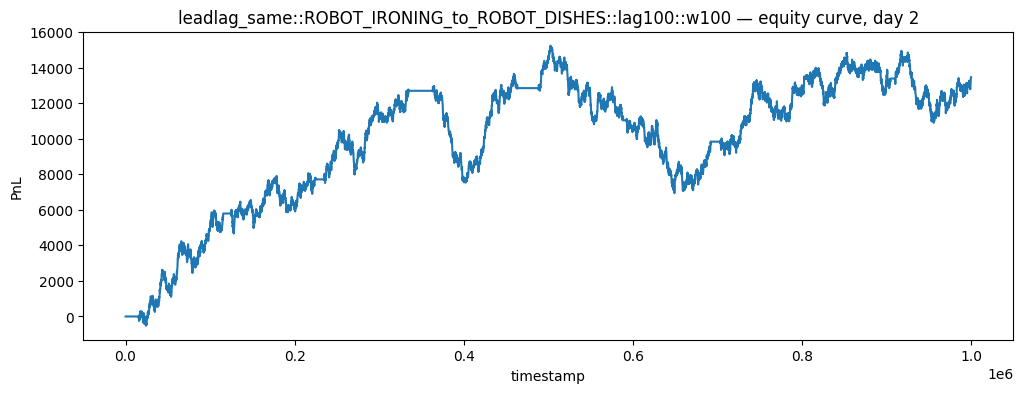

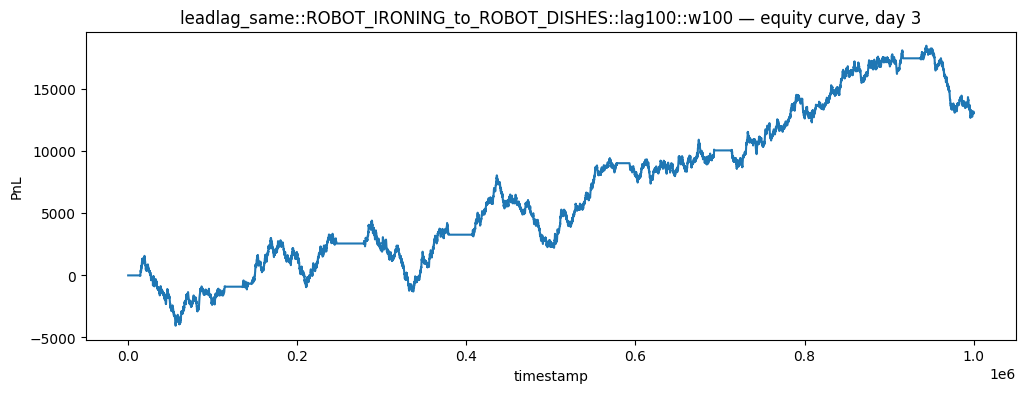

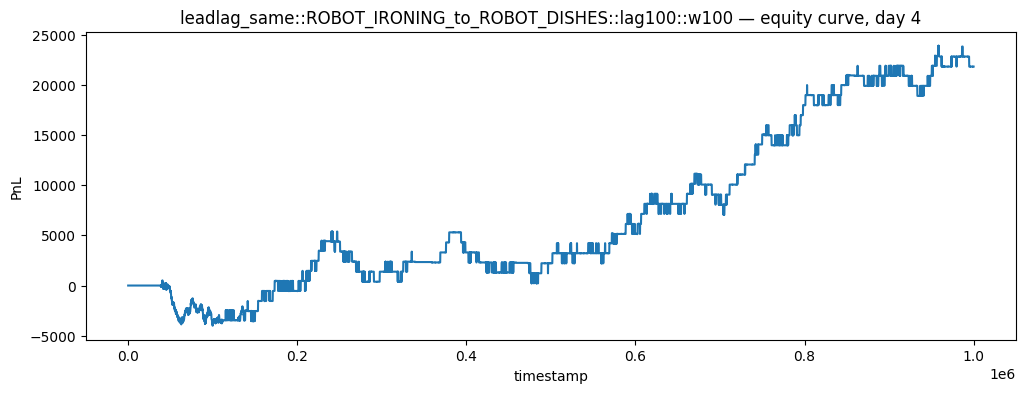

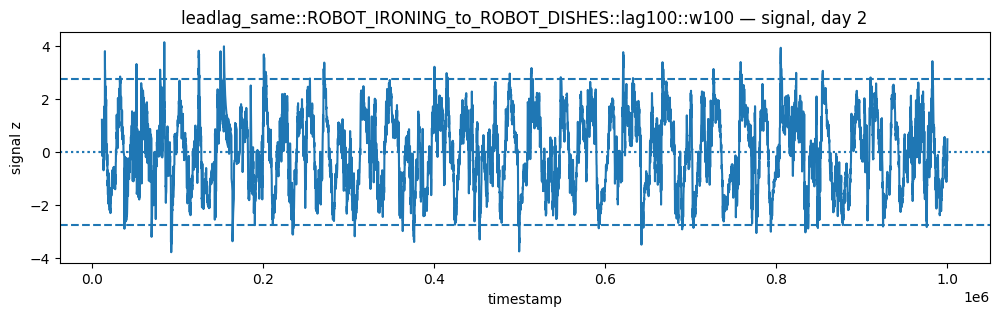

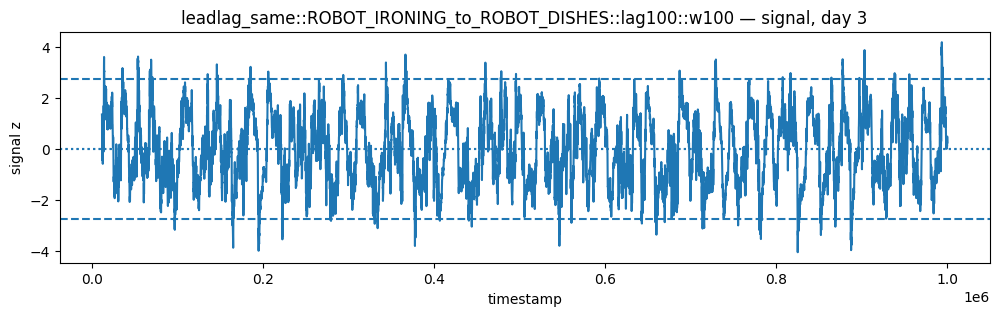

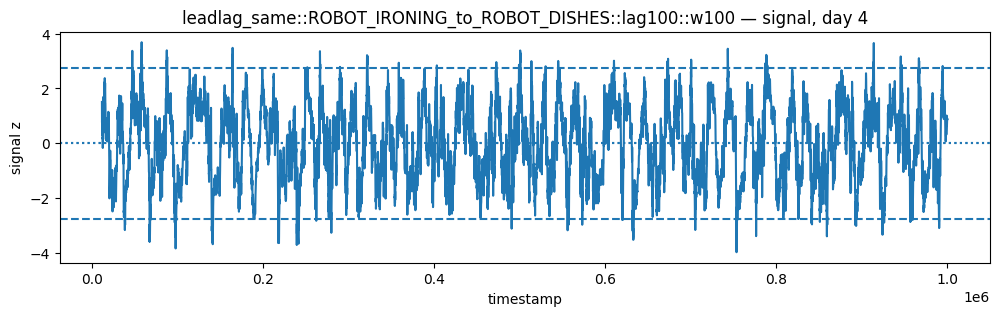

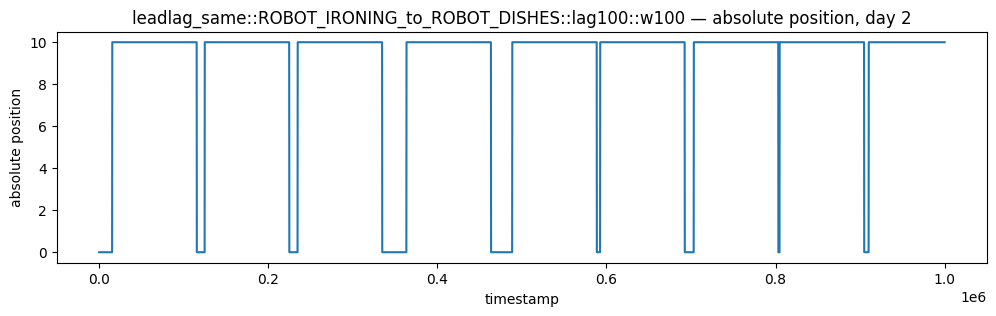

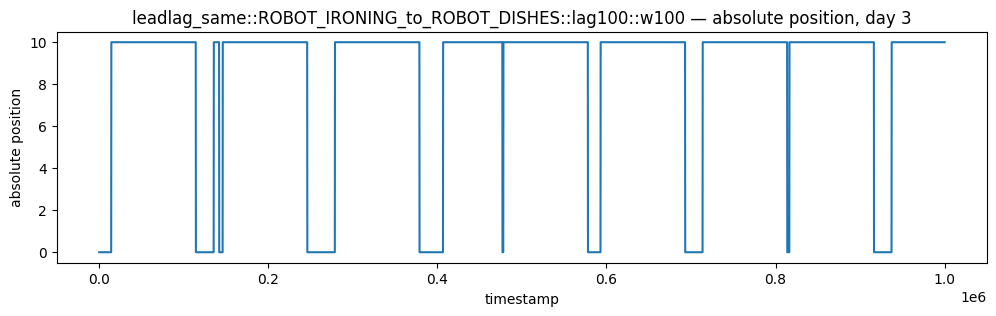

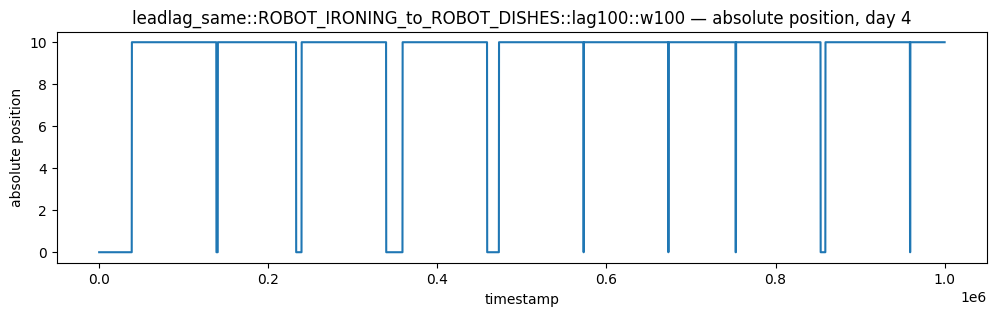

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — DEEP DIVE TOP CANDIDATE
# ════════════════════════════════════════════════════════════════════════════

# Default: best overall from scan.
TOP_CANDIDATE_NAME = scan_sorted.iloc[0]["candidate"]

# Or manually override after looking at results:
# TOP_CANDIDATE_NAME = "..."

top_row = scan_sorted[scan_sorted["candidate"] == TOP_CANDIDATE_NAME].iloc[0]
top_candidate = next(c for c in robot_candidates if c["name"] == TOP_CANDIDATE_NAME)

summary, day_results, curve, trade_log = backtest_robot_candidate(
    candidate=top_candidate,
    bid=bid,
    ask=ask,
    mid=mid,
    entry_z=top_row["entry_z"],
    exit_z=top_row["exit_z"],
    qty=int(top_row["qty"]),
    max_hold=int(top_row["max_hold"]),
    position_limits=POSITION_LIMITS,
    flatten_at_end=True,
)

print("Selected candidate:")
display(pd.DataFrame([summary]))

print("Day results:")
display(day_results)

print("Candidate details:")
print("Name:", top_candidate["name"])
print("Family:", top_candidate["family"])
print("Description:", top_candidate["description"])
print("Weights:", top_candidate["weights"])
print()
print("Params:")
print("entry_z:", top_row["entry_z"])
print("exit_z:", top_row["exit_z"])
print("qty:", int(top_row["qty"]))
print("max_hold:", int(top_row["max_hold"]))

print("Trade log head:")
display(trade_log.head(50))

print("Trade log tail:")
display(trade_log.tail(50))

for day, g in curve.groupby("day"):
    plt.figure(figsize=(12, 4))
    plt.plot(g["timestamp"], g["equity"])
    plt.title(f"{TOP_CANDIDATE_NAME} — equity curve, day {day}")
    plt.xlabel("timestamp")
    plt.ylabel("PnL")
    plt.show()

for day, g in curve.groupby("day"):
    plt.figure(figsize=(12, 3))
    plt.plot(g["timestamp"], g["signal"])
    plt.axhline(top_row["entry_z"], linestyle="--")
    plt.axhline(-top_row["entry_z"], linestyle="--")
    plt.axhline(top_row["exit_z"], linestyle=":")
    plt.axhline(-top_row["exit_z"], linestyle=":")
    plt.title(f"{TOP_CANDIDATE_NAME} — signal, day {day}")
    plt.xlabel("timestamp")
    plt.ylabel("signal z")
    plt.show()

for day, g in curve.groupby("day"):
    plt.figure(figsize=(12, 3))
    plt.plot(g["timestamp"], g["abs_position"])
    plt.title(f"{TOP_CANDIDATE_NAME} — absolute position, day {day}")
    plt.xlabel("timestamp")
    plt.ylabel("absolute position")
    plt.show()

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — LOCAL STRESS TEST AROUND TOP CANDIDATE
# ════════════════════════════════════════════════════════════════════════════

stress_rows = []

entry_base = float(top_row["entry_z"])
exit_base = float(top_row["exit_z"])
qty_base = int(top_row["qty"])
hold_base = int(top_row["max_hold"])

ENTRY_TESTS = sorted(set([
    max(0.5, entry_base - 0.5),
    entry_base,
    entry_base + 0.5,
]))

EXIT_TESTS = sorted(set([
    max(0.0, exit_base - 0.25),
    exit_base,
    exit_base + 0.25,
]))

QTY_TESTS = sorted(set([
    max(1, qty_base - 2),
    qty_base,
    min(10, qty_base + 2),
]))

HOLD_TESTS = sorted(set([
    max(10, hold_base // 2),
    hold_base,
    hold_base * 2,
]))

for entry_z in ENTRY_TESTS:
    for exit_z in EXIT_TESTS:
        if exit_z >= entry_z:
            continue

        for qty in QTY_TESTS:
            for max_hold in HOLD_TESTS:
                s, _, _, _ = backtest_robot_candidate(
                    candidate=top_candidate,
                    bid=bid,
                    ask=ask,
                    mid=mid,
                    entry_z=entry_z,
                    exit_z=exit_z,
                    qty=qty,
                    max_hold=max_hold,
                    position_limits=POSITION_LIMITS,
                    flatten_at_end=True,
                )

                stress_rows.append(s)

stress = pd.DataFrame(stress_rows)

stress["robust_score"] = (
    stress["total_pnl"]
    + 2.0 * stress["min_day_pnl"]
    + 500.0 * stress["positive_days"]
    - 10.0 * stress["total_trades"].clip(lower=0)
)

stress_sorted = stress.sort_values(
    ["positive_days", "min_day_pnl", "total_pnl", "robust_score"],
    ascending=False,
).reset_index(drop=True)

display(
    stress_sorted[
        [
            "family",
            "candidate",
            "entry_z",
            "exit_z",
            "qty",
            "max_hold",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "num_days",
            "total_trades",
            "mean_hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)

,family,candidate,entry_z,exit_z,qty,max_hold,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.75,0.00,10,1000,48230.0,13030.0,3,3,29,0.651852,"{2: 13420.0, 3: 13030.0, 4: 21780.0}",75500.0
1,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.75,0.00,8,1000,38584.0,10424.0,3,3,29,0.651852,"{2: 10736.0, 3: 10424.0, 4: 17424.0}",60642.0
2,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.25,0.00,8,2000,18264.0,-504.0,2,3,19,0.600000,"{2: 15280.0, 3: -504.0, 4: 3488.0}",18066.0
3,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.25,0.00,10,2000,22830.0,-630.0,2,3,19,0.600000,"{2: 19100.0, 3: -630.0, 4: 4360.0}",22380.0
4,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.25,0.00,8,1000,23760.0,-768.0,2,3,32,0.503030,"{2: 10368.0, 3: 14160.0, 4: -768.0}",22904.0
5,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.25,0.00,10,1000,29700.0,-960.0,2,3,32,0.503030,"{2: 12960.0, 3: 17700.0, 4: -960.0}",28460.0
6,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.75,0.00,8,2000,11104.0,-1152.0,2,3,17,0.411111,"{2: 6576.0, 3: -1152.0, 4: 5680.0}",9630.0
7,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.75,0.00,10,2000,13880.0,-1440.0,2,3,17,0.411111,"{2: 8220.0, 3: -1440.0, 4: 7100.0}",11830.0
8,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.25,0.00,8,500,2304.0,-1568.0,2,3,56,0.411306,"{2: 944.0, 3: -1568.0, 4: 2928.0}",-392.0
9,leadlag_same,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2.25,0.00,10,500,2880.0,-1960.0,2,3,56,0.411306,"{2: 1180.0, 3: -1960.0, 4: 3660.0}",-600.0


In [15]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 — EXPORT STRATEGY CONFIG FOR IMPLEMENTATION
# ════════════════════════════════════════════════════════════════════════════

best_impl_row = stress_sorted.iloc[0] if len(stress_sorted) else top_row

implementation_config = {
    "category": "Domestic Robots",
    "candidate": best_impl_row["candidate"],
    "family": best_impl_row["family"],
    "description": best_impl_row["description"],
    "entry_z": float(best_impl_row["entry_z"]),
    "exit_z": float(best_impl_row["exit_z"]),
    "qty": int(best_impl_row["qty"]),
    "max_hold": int(best_impl_row["max_hold"]),
    "position_limits": {p: POSITION_LIMITS[p] for p in ROBOT_PRODUCTS},
    "products": ROBOT_PRODUCTS,
}

chosen_candidate = next(
    c for c in robot_candidates
    if c["name"] == implementation_config["candidate"]
)

implementation_config["weights"] = chosen_candidate["weights"]

print("Implementation config:")
display(implementation_config)

print()
print("Important interpretation:")
print("- signal > entry_z: short positive-weight legs / long negative-weight legs")
print("- signal < -entry_z: long positive-weight legs / short negative-weight legs")
print("- exit when abs(signal) <= exit_z or max_hold is reached")
print("- always enforce per-product position limit of 10")

Implementation config:


{'category': 'Domestic Robots',
 'candidate': 'leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::lag100::w100',
 'family': 'leadlag_same',
 'description': 'ROBOT_IRONING return over lag=100 predicts same-direction ROBOT_DISHES, window=100',
 'entry_z': 2.75,
 'exit_z': 0.0,
 'qty': 10,
 'max_hold': 1000,
 'position_limits': {'ROBOT_VACUUMING': 10,
  'ROBOT_MOPPING': 10,
  'ROBOT_DISHES': 10,
  'ROBOT_LAUNDRY': 10,
  'ROBOT_IRONING': 10},
 'products': ['ROBOT_VACUUMING',
  'ROBOT_MOPPING',
  'ROBOT_DISHES',
  'ROBOT_LAUNDRY',
  'ROBOT_IRONING'],
 'weights': {'ROBOT_DISHES': 1.0}}


Important interpretation:
- signal > entry_z: short positive-weight legs / long negative-weight legs
- signal < -entry_z: long positive-weight legs / short negative-weight legs
- exit when abs(signal) <= exit_z or max_hold is reached
- always enforce per-product position limit of 10


In [16]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — STRICT ROBOT LEAD-LAG SIMULATOR
# ════════════════════════════════════════════════════════════════════════════

ROBOT_PRODUCTS = [
    "ROBOT_VACUUMING",
    "ROBOT_MOPPING",
    "ROBOT_DISHES",
    "ROBOT_LAUNDRY",
    "ROBOT_IRONING",
]

robot_prices = prices[prices["product"].isin(ROBOT_PRODUCTS)].copy()
robot_prices = robot_prices.sort_values(["file_day", "timestamp", "product"]).reset_index(drop=True)

# Wide mid-price table, one row per timestamp/day.
robot_mid = (
    robot_prices
    .pivot_table(
        index=["file_day", "timestamp"],
        columns="product",
        values="mid_price",
        aggfunc="last",
    )
    .sort_index()
)

# Wide best bid/ask tables for execution.
robot_bid1 = (
    robot_prices
    .pivot_table(
        index=["file_day", "timestamp"],
        columns="product",
        values="bid_price_1",
        aggfunc="last",
    )
    .sort_index()
)

robot_ask1 = (
    robot_prices
    .pivot_table(
        index=["file_day", "timestamp"],
        columns="product",
        values="ask_price_1",
        aggfunc="last",
    )
    .sort_index()
)

print("robot_mid shape:", robot_mid.shape)
display(robot_mid.head())


def make_leadlag_signal_for_day(day_mid, lead_product, lag, window):
    """
    Signal used by the discovered robot lead-lag candidates.

    It uses only current/past mids:
    - lagged return of the lead product
    - rolling z-score of that lagged return

    Convention:
    signal > +entry_z  => SELL target
    signal < -entry_z  => BUY target
    """
    lead_mid = day_mid[lead_product].astype(float)

    lead_ret = lead_mid - lead_mid.shift(lag)
    roll_mean = lead_ret.rolling(window, min_periods=window).mean()
    roll_std = lead_ret.rolling(window, min_periods=window).std(ddof=0)

    z = (lead_ret - roll_mean) / roll_std.replace(0, np.nan)
    return z.replace([np.inf, -np.inf], np.nan)


def simulate_one_leadlag_config(
    config,
    invert_signal=False,
    verbose=False,
):
    """
    Strict single-config backtest.

    Each config trades exactly one target product at a time:
    - flat -> enter full qty on threshold
    - position -> exit on abs(signal) <= exit_z or max_hold
    - flatten at end of day
    - uses best ask for BUY, best bid for SELL
    - enforces position limit
    """
    lead = config["lead_product"]
    target = config["target_product"]
    lag = int(config["lag"])
    window = int(config["window"])
    entry_z = float(config["entry_z"])
    exit_z = float(config["exit_z"])
    qty = int(config["qty"])
    max_hold = int(config["max_hold"])
    limit = int(config.get("position_limit", POSITION_LIMITS[target]))

    all_trade_logs = []
    day_rows = []
    equity_rows = []

    for day in DAYS:
        day_mid = robot_mid.loc[day].copy()
        day_bid = robot_bid1.loc[day].copy()
        day_ask = robot_ask1.loc[day].copy()

        signal = make_leadlag_signal_for_day(day_mid, lead, lag, window)
        if invert_signal:
            signal = -signal

        pos = 0
        cash = 0.0
        entry_time = None
        trades = []
        wins = 0
        completed_trades = 0
        entry_cash = None

        timestamps = list(day_mid.index)

        for ts in timestamps:
            sig = signal.loc[ts]
            mid = float(day_mid.loc[ts, target])
            bid = float(day_bid.loc[ts, target])
            ask = float(day_ask.loc[ts, target])

            # Mark-to-market equity before/after possible action.
            equity_before = cash + pos * mid

            if np.isfinite(sig):
                # Exit logic first.
                if pos != 0:
                    held_ticks = (ts - entry_time) // 100 if entry_time is not None else 0
                    should_exit_signal = abs(sig) <= exit_z
                    should_exit_hold = held_ticks >= max_hold

                    if should_exit_signal or should_exit_hold:
                        reason = "signal_exit" if should_exit_signal else "max_hold"

                        if pos > 0:
                            # Close long by selling at bid.
                            cash += pos * bid
                            side = "SELL"
                            px = bid
                            qty_done = abs(pos)
                        else:
                            # Close short by buying at ask.
                            cash -= abs(pos) * ask
                            side = "BUY"
                            px = ask
                            qty_done = abs(pos)

                        trade_pnl = cash - entry_cash if entry_cash is not None else np.nan
                        if np.isfinite(trade_pnl) and trade_pnl > 0:
                            wins += 1
                        completed_trades += 1

                        trades.append({
                            "day": day,
                            "timestamp": ts,
                            "product": target,
                            "side": side,
                            "quantity": qty_done,
                            "price": px,
                            "reason": reason,
                            "signal": sig,
                            "position_after": 0,
                            "trade_pnl": trade_pnl,
                        })

                        pos = 0
                        entry_time = None
                        entry_cash = None

                # Entry logic after exit.
                if pos == 0:
                    desired_pos = 0

                    if sig > entry_z:
                        desired_pos = -qty
                    elif sig < -entry_z:
                        desired_pos = qty

                    if desired_pos != 0 and abs(desired_pos) <= limit:
                        entry_cash = cash

                        if desired_pos > 0:
                            # Buy at ask.
                            cash -= desired_pos * ask
                            side = "BUY"
                            px = ask
                        else:
                            # Sell at bid.
                            cash += abs(desired_pos) * bid
                            side = "SELL"
                            px = bid

                        pos = desired_pos
                        entry_time = ts

                        trades.append({
                            "day": day,
                            "timestamp": ts,
                            "product": target,
                            "side": side,
                            "quantity": abs(desired_pos),
                            "price": px,
                            "reason": "entry",
                            "signal": sig,
                            "position_after": pos,
                            "trade_pnl": np.nan,
                        })

            equity_after = cash + pos * mid
            equity_rows.append({
                "candidate": config["candidate"],
                "day": day,
                "timestamp": ts,
                "equity": equity_after,
                "signal": sig,
                "position": pos,
            })

        # End-of-day flatten.
        if pos != 0:
            ts = timestamps[-1]
            mid = float(day_mid.loc[ts, target])
            bid = float(day_bid.loc[ts, target])
            ask = float(day_ask.loc[ts, target])
            sig = signal.loc[ts]

            if pos > 0:
                cash += pos * bid
                side = "SELL"
                px = bid
                qty_done = abs(pos)
            else:
                cash -= abs(pos) * ask
                side = "BUY"
                px = ask
                qty_done = abs(pos)

            trade_pnl = cash - entry_cash if entry_cash is not None else np.nan
            if np.isfinite(trade_pnl) and trade_pnl > 0:
                wins += 1
            completed_trades += 1

            trades.append({
                "day": day,
                "timestamp": ts,
                "product": target,
                "side": side,
                "quantity": qty_done,
                "price": px,
                "reason": "end_of_day_flatten",
                "signal": sig,
                "position_after": 0,
                "trade_pnl": trade_pnl,
            })

            pos = 0
            entry_time = None
            entry_cash = None

        day_pnl = cash
        hit_rate = wins / completed_trades if completed_trades else np.nan

        day_rows.append({
            "candidate": config["candidate"],
            "day": day,
            "day_pnl": day_pnl,
            "trades": completed_trades,
            "wins": wins,
            "hit_rate": hit_rate,
            "final_abs_position": abs(pos),
        })

        for tr in trades:
            tr["candidate"] = config["candidate"]
            tr["family"] = config["family"]
            tr["lead_product"] = lead
            tr["target_product"] = target
            tr["lag"] = lag
            tr["window"] = window
            tr["entry_z"] = entry_z
            tr["exit_z"] = exit_z
            tr["max_hold"] = max_hold
            tr["invert_signal"] = invert_signal

        all_trade_logs.extend(trades)

    day_df = pd.DataFrame(day_rows)
    trade_df = pd.DataFrame(all_trade_logs)
    equity_df = pd.DataFrame(equity_rows)

    total_pnl = day_df["day_pnl"].sum()
    min_day_pnl = day_df["day_pnl"].min()
    positive_days = int((day_df["day_pnl"] > 0).sum())
    total_trades = int(day_df["trades"].sum())
    mean_hit_rate = day_df["hit_rate"].mean()

    summary = {
        "candidate": config["candidate"],
        "family": config["family"],
        "lead_product": lead,
        "target_product": target,
        "lag": lag,
        "window": window,
        "entry_z": entry_z,
        "exit_z": exit_z,
        "qty": qty,
        "max_hold": max_hold,
        "invert_signal": invert_signal,
        "total_pnl": total_pnl,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": len(day_df),
        "total_trades": total_trades,
        "mean_hit_rate": mean_hit_rate,
        "day_pnls": dict(zip(day_df["day"], day_df["day_pnl"])),
        "robust_score": total_pnl + 2.0 * min_day_pnl,
    }

    if verbose:
        display(pd.DataFrame([summary]))
        display(day_df)
        display(trade_df.head(20))
        display(trade_df.tail(20))

    return summary, day_df, trade_df, equity_df


PRIMARY_ROBOT_CONFIG = {
    "category": "Domestic Robots",
    "candidate": "leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::lag100::w100",
    "family": "leadlag_same",
    "description": "ROBOT_IRONING return over lag=100 predicts same-direction ROBOT_DISHES, window=100",
    "lead_product": "ROBOT_IRONING",
    "target_product": "ROBOT_DISHES",
    "lag": 100,
    "window": 100,
    "entry_z": 2.75,
    "exit_z": 0.0,
    "qty": 10,
    "max_hold": 1000,
    "position_limit": 10,
}

SECONDARY_ROBOT_CONFIG = {
    "category": "Domestic Robots",
    "candidate": "leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING::lag20::w100",
    "family": "leadlag_same",
    "description": "ROBOT_VACUUMING return over lag=20 predicts same-direction ROBOT_MOPPING, window=100",
    "lead_product": "ROBOT_VACUUMING",
    "target_product": "ROBOT_MOPPING",
    "lag": 20,
    "window": 100,
    "entry_z": 3.00,
    "exit_z": 0.0,
    "qty": 10,
    "max_hold": 750,
    "position_limit": 10,
}

print("Primary config:")
display(pd.DataFrame([PRIMARY_ROBOT_CONFIG]))

print("Secondary config:")
display(pd.DataFrame([SECONDARY_ROBOT_CONFIG]))

robot_mid shape: (30000, 5)


product             ROBOT_DISHES  ROBOT_IRONING  ROBOT_LAUNDRY  ROBOT_MOPPING  \
file_day timestamp                                                              
2        0               10000.0        10000.0        10000.0        10000.0   
         100              9979.5         9990.0         9990.5        10012.0   
         200              9998.0         9980.0        10007.5        10001.5   
         300             10000.0         9980.0        10006.0        10010.5   
         400              9983.5         9980.0        10000.0        10010.5   

product             ROBOT_VACUUMING  
file_day timestamp                   
2        0                  10000.0  
         100                 9996.5  
         200                10016.5  
         300                10013.5  
         400                10010.5

Primary config:


,category,candidate,family,description,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,position_limit
0,Domestic Robots,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING return over lag=100 predicts sam...,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,10


Secondary config:


,category,candidate,family,description,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,position_limit
0,Domestic Robots,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING return over lag=20 predicts sa...,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,10,750,10


In [17]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 — PRIMARY SANITY, SIGN TEST, AND LOCAL SENSITIVITY
# ════════════════════════════════════════════════════════════════════════════

# 10.1 Re-run selected primary alpha cleanly.
primary_summary, primary_day_df, primary_trades, primary_equity = simulate_one_leadlag_config(
    PRIMARY_ROBOT_CONFIG,
    invert_signal=False,
    verbose=False,
)

print("Primary strict re-test:")
display(pd.DataFrame([primary_summary]))
display(primary_day_df)
display(primary_trades.head(20))
display(primary_trades.tail(20))


# 10.2 Sign convention test.
# If inverted sign is bad, the discovered direction is confirmed.
primary_inverted_summary, primary_inverted_day_df, primary_inverted_trades, primary_inverted_equity = simulate_one_leadlag_config(
    PRIMARY_ROBOT_CONFIG,
    invert_signal=True,
    verbose=False,
)

sign_check = pd.DataFrame([primary_summary, primary_inverted_summary])
print("Sign convention check:")
display(sign_check[[
    "candidate",
    "invert_signal",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "mean_hit_rate",
    "day_pnls",
    "robust_score",
]])


# 10.3 Small local sensitivity around selected winner.
local_rows = []

for entry_z in [2.50, 2.75, 3.00]:
    for max_hold in [750, 1000, 1250]:
        for qty in [8, 10]:
            cfg = PRIMARY_ROBOT_CONFIG.copy()
            cfg["entry_z"] = entry_z
            cfg["max_hold"] = max_hold
            cfg["qty"] = qty
            cfg["candidate"] = (
                f"primary_sensitivity::IRONING_to_DISHES"
                f"::lag{cfg['lag']}::w{cfg['window']}"
                f"::ez{entry_z}::hold{max_hold}::q{qty}"
            )

            summary, _, _, _ = simulate_one_leadlag_config(cfg, invert_signal=False)
            local_rows.append(summary)

primary_sensitivity = pd.DataFrame(local_rows).sort_values(
    ["positive_days", "min_day_pnl", "total_pnl"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("Primary local sensitivity:")
display(primary_sensitivity[[
    "candidate",
    "entry_z",
    "exit_z",
    "qty",
    "max_hold",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "mean_hit_rate",
    "day_pnls",
    "robust_score",
]])

print("Best sensitivity row:")
display(primary_sensitivity.head(1))

Primary strict re-test:


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,False,-45860.0,-23330.0,0,3,29,0.277778,"{2: -7590.0, 3: -14940.0, 4: -23330.0}",-92520.0


,candidate,day,day_pnl,trades,wins,hit_rate,final_abs_position
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,-7590.0,9,3,0.333333,0
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,3,-14940.0,10,2,0.200000,0
2,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,4,-23330.0,10,3,0.300000,0


,day,timestamp,product,side,quantity,price,reason,signal,position_after,trade_pnl,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,max_hold,invert_signal
0,2,33100,ROBOT_DISHES,BUY,10,9834.0,entry,-2.751242,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
1,2,133100,ROBOT_DISHES,SELL,10,9109.0,max_hold,0.805508,0,-7250.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
2,2,150500,ROBOT_DISHES,BUY,10,9136.0,entry,-3.806675,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
3,2,250500,ROBOT_DISHES,SELL,10,9127.0,max_hold,-0.509773,0,-90.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
4,2,255000,ROBOT_DISHES,BUY,10,9185.0,entry,-2.775566,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
5,2,355000,ROBOT_DISHES,SELL,10,9319.0,max_hold,-0.669474,0,1340.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
6,2,363400,ROBOT_DISHES,SELL,10,9364.0,entry,3.007916,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
7,2,463400,ROBOT_DISHES,BUY,10,9393.0,max_hold,-0.073114,0,-290.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
8,2,488500,ROBOT_DISHES,BUY,10,9364.0,entry,-2.962718,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
9,2,588500,ROBOT_DISHES,SELL,10,9531.0,max_hold,-2.040792,0,1670.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False


,day,timestamp,product,side,quantity,price,reason,signal,position_after,trade_pnl,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,max_hold,invert_signal
38,4,38600,ROBOT_DISHES,SELL,10,10543.0,entry,3.021617,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
39,4,138600,ROBOT_DISHES,BUY,10,10304.0,max_hold,-0.933415,0,2390.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
40,4,140300,ROBOT_DISHES,SELL,10,10196.0,entry,3.213106,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
41,4,232900,ROBOT_DISHES,BUY,10,10904.0,signal_exit,0.000000,0,-7080.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
42,4,239400,ROBOT_DISHES,SELL,10,10896.0,entry,2.807369,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
43,4,339400,ROBOT_DISHES,BUY,10,10704.0,max_hold,0.687534,0,1920.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
44,4,358800,ROBOT_DISHES,BUY,10,10604.0,entry,-2.951384,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
45,4,458800,ROBOT_DISHES,SELL,10,10596.0,max_hold,0.501572,0,-80.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
46,4,472800,ROBOT_DISHES,BUY,10,10504.0,entry,-2.975268,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
47,4,572800,ROBOT_DISHES,SELL,10,10196.0,max_hold,1.030622,0,-3080.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False


...

,candidate,invert_signal,total_pnl,min_day_pnl,positive_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,False,-45860.0,-23330.0,0,29,0.277778,"{2: -7590.0, 3: -14940.0, 4: -23330.0}",-92520.0
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,True,41610.0,6310.0,3,29,0.614815,"{2: 6310.0, 3: 13520.0, 4: 21780.0}",54230.0


Primary local sensitivity:


,candidate,entry_z,exit_z,qty,max_hold,total_pnl,min_day_pnl,positive_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,primary_sensitivity::IRONING_to_DISHES::lag100...,2.50,0.0,8,1250,-584.0,-4368.0,1,25,0.486111,"{2: -4368.0, 3: -2128.0, 4: 5912.0}",-9320.0
1,primary_sensitivity::IRONING_to_DISHES::lag100...,2.50,0.0,10,1250,-730.0,-5460.0,1,25,0.486111,"{2: -5460.0, 3: -2660.0, 4: 7390.0}",-11650.0
2,primary_sensitivity::IRONING_to_DISHES::lag100...,2.75,0.0,8,750,-5392.0,-10792.0,1,36,0.398019,"{2: 10592.0, 3: -5192.0, 4: -10792.0}",-26976.0
3,primary_sensitivity::IRONING_to_DISHES::lag100...,2.75,0.0,10,750,-6740.0,-13490.0,1,36,0.398019,"{2: 13240.0, 3: -6490.0, 4: -13490.0}",-33720.0
4,primary_sensitivity::IRONING_to_DISHES::lag100...,3.00,0.0,8,1250,-26912.0,-15432.0,1,22,0.327381,"{2: -13008.0, 3: -15432.0, 4: 1528.0}",-57776.0
5,primary_sensitivity::IRONING_to_DISHES::lag100...,3.00,0.0,10,1250,-33640.0,-19290.0,1,22,0.327381,"{2: -16260.0, 3: -19290.0, 4: 1910.0}",-72220.0
6,primary_sensitivity::IRONING_to_DISHES::lag100...,2.75,0.0,8,1250,-6616.0,-2872.0,0,25,0.444444,"{2: -2872.0, 3: -2008.0, 4: -1736.0}",-12360.0
7,primary_sensitivity::IRONING_to_DISHES::lag100...,2.75,0.0,10,1250,-8270.0,-3590.0,0,25,0.444444,"{2: -3590.0, 3: -2510.0, 4: -2170.0}",-15450.0
8,primary_sensitivity::IRONING_to_DISHES::lag100...,3.00,0.0,8,750,-14032.0,-7848.0,0,30,0.426263,"{2: -7848.0, 3: -5856.0, 4: -328.0}",-29728.0
9,primary_sensitivity::IRONING_to_DISHES::lag100...,3.00,0.0,10,750,-17540.0,-9810.0,0,30,0.426263,"{2: -9810.0, 3: -7320.0, 4: -410.0}",-37160.0


Best sensitivity row:


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,primary_sensitivity::IRONING_to_DISHES::lag100...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.5,0.0,8,1250,False,-584.0,-4368.0,1,3,25,0.486111,"{2: -4368.0, 3: -2128.0, 4: 5912.0}",-9320.0


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — COMBINED ROBOT STRATEGY TEST
# ════════════════════════════════════════════════════════════════════════════

def simulate_combined_leadlag_configs(configs, verbose=False):
    """
    Combined multi-alpha simulator.

    Each alpha manages its own virtual position, but execution is blocked
    if aggregate product position would breach the ±10 product limit.

    This is necessary before implementation because multiple robot alphas
    can theoretically trade overlapping products.
    """
    all_trade_logs = []
    day_rows = []
    equity_rows = []

    for day in DAYS:
        day_mid = robot_mid.loc[day].copy()
        day_bid = robot_bid1.loc[day].copy()
        day_ask = robot_ask1.loc[day].copy()
        timestamps = list(day_mid.index)

        # Precompute signals.
        signals = {}
        for i, cfg in enumerate(configs):
            sig = make_leadlag_signal_for_day(
                day_mid,
                cfg["lead_product"],
                int(cfg["lag"]),
                int(cfg["window"]),
            )
            signals[i] = sig

        strategy_state = {}
        product_pos = {p: 0 for p in ROBOT_PRODUCTS}
        cash = 0.0
        blocked_entries = 0
        trades = []
        completed_trades = 0
        wins = 0

        for i, cfg in enumerate(configs):
            strategy_state[i] = {
                "pos": 0,
                "entry_time": None,
                "entry_cash": None,
            }

        for ts in timestamps:
            # Process exits first for all strategies.
            for i, cfg in enumerate(configs):
                target = cfg["target_product"]
                sig = signals[i].loc[ts]
                state = strategy_state[i]
                pos = state["pos"]

                if pos == 0 or not np.isfinite(sig):
                    continue

                held_ticks = (ts - state["entry_time"]) // 100 if state["entry_time"] is not None else 0
                should_exit_signal = abs(sig) <= float(cfg["exit_z"])
                should_exit_hold = held_ticks >= int(cfg["max_hold"])

                if should_exit_signal or should_exit_hold:
                    reason = "signal_exit" if should_exit_signal else "max_hold"

                    bid = float(day_bid.loc[ts, target])
                    ask = float(day_ask.loc[ts, target])

                    if pos > 0:
                        cash += pos * bid
                        side = "SELL"
                        px = bid
                        qty_done = abs(pos)
                    else:
                        cash -= abs(pos) * ask
                        side = "BUY"
                        px = ask
                        qty_done = abs(pos)

                    product_pos[target] -= pos

                    trade_pnl = cash - state["entry_cash"] if state["entry_cash"] is not None else np.nan
                    if np.isfinite(trade_pnl) and trade_pnl > 0:
                        wins += 1
                    completed_trades += 1

                    trades.append({
                        "day": day,
                        "timestamp": ts,
                        "strategy_index": i,
                        "candidate": cfg["candidate"],
                        "family": cfg["family"],
                        "lead_product": cfg["lead_product"],
                        "target_product": target,
                        "side": side,
                        "quantity": qty_done,
                        "price": px,
                        "reason": reason,
                        "signal": sig,
                        "strategy_position_after": 0,
                        "aggregate_product_position_after": product_pos[target],
                        "trade_pnl": trade_pnl,
                    })

                    state["pos"] = 0
                    state["entry_time"] = None
                    state["entry_cash"] = None

            # Then process entries.
            for i, cfg in enumerate(configs):
                target = cfg["target_product"]
                sig = signals[i].loc[ts]
                state = strategy_state[i]

                if state["pos"] != 0 or not np.isfinite(sig):
                    continue

                entry_z = float(cfg["entry_z"])
                qty = int(cfg["qty"])
                limit = int(cfg.get("position_limit", POSITION_LIMITS[target]))

                desired_pos = 0

                if sig > entry_z:
                    desired_pos = -qty
                elif sig < -entry_z:
                    desired_pos = qty

                if desired_pos == 0:
                    continue

                new_agg_pos = product_pos[target] + desired_pos

                if abs(new_agg_pos) > limit:
                    blocked_entries += 1
                    continue

                bid = float(day_bid.loc[ts, target])
                ask = float(day_ask.loc[ts, target])

                state["entry_cash"] = cash

                if desired_pos > 0:
                    cash -= desired_pos * ask
                    side = "BUY"
                    px = ask
                else:
                    cash += abs(desired_pos) * bid
                    side = "SELL"
                    px = bid

                state["pos"] = desired_pos
                state["entry_time"] = ts
                product_pos[target] = new_agg_pos

                trades.append({
                    "day": day,
                    "timestamp": ts,
                    "strategy_index": i,
                    "candidate": cfg["candidate"],
                    "family": cfg["family"],
                    "lead_product": cfg["lead_product"],
                    "target_product": target,
                    "side": side,
                    "quantity": abs(desired_pos),
                    "price": px,
                    "reason": "entry",
                    "signal": sig,
                    "strategy_position_after": desired_pos,
                    "aggregate_product_position_after": product_pos[target],
                    "trade_pnl": np.nan,
                })

            # Combined mark-to-market equity.
            mtm = cash
            for p, ppos in product_pos.items():
                if ppos != 0:
                    mtm += ppos * float(day_mid.loc[ts, p])

            equity_row = {
                "day": day,
                "timestamp": ts,
                "equity": mtm,
                "blocked_entries": blocked_entries,
            }
            for p in ROBOT_PRODUCTS:
                equity_row[f"pos_{p}"] = product_pos[p]
            equity_rows.append(equity_row)

        # End-of-day flatten all remaining positions.
        ts = timestamps[-1]

        for i, cfg in enumerate(configs):
            target = cfg["target_product"]
            state = strategy_state[i]
            pos = state["pos"]

            if pos == 0:
                continue

            sig = signals[i].loc[ts]
            bid = float(day_bid.loc[ts, target])
            ask = float(day_ask.loc[ts, target])

            if pos > 0:
                cash += pos * bid
                side = "SELL"
                px = bid
                qty_done = abs(pos)
            else:
                cash -= abs(pos) * ask
                side = "BUY"
                px = ask
                qty_done = abs(pos)

            product_pos[target] -= pos

            trade_pnl = cash - state["entry_cash"] if state["entry_cash"] is not None else np.nan
            if np.isfinite(trade_pnl) and trade_pnl > 0:
                wins += 1
            completed_trades += 1

            trades.append({
                "day": day,
                "timestamp": ts,
                "strategy_index": i,
                "candidate": cfg["candidate"],
                "family": cfg["family"],
                "lead_product": cfg["lead_product"],
                "target_product": target,
                "side": side,
                "quantity": qty_done,
                "price": px,
                "reason": "end_of_day_flatten",
                "signal": sig,
                "strategy_position_after": 0,
                "aggregate_product_position_after": product_pos[target],
                "trade_pnl": trade_pnl,
            })

            state["pos"] = 0
            state["entry_time"] = None
            state["entry_cash"] = None

        day_pnl = cash
        hit_rate = wins / completed_trades if completed_trades else np.nan

        day_rows.append({
            "day": day,
            "day_pnl": day_pnl,
            "trades": completed_trades,
            "wins": wins,
            "hit_rate": hit_rate,
            "blocked_entries": blocked_entries,
            **{f"final_pos_{p}": product_pos[p] for p in ROBOT_PRODUCTS},
        })

        all_trade_logs.extend(trades)

    day_df = pd.DataFrame(day_rows)
    trade_df = pd.DataFrame(all_trade_logs)
    equity_df = pd.DataFrame(equity_rows)

    total_pnl = day_df["day_pnl"].sum()
    min_day_pnl = day_df["day_pnl"].min()
    positive_days = int((day_df["day_pnl"] > 0).sum())
    total_trades = int(day_df["trades"].sum())
    mean_hit_rate = day_df["hit_rate"].mean()

    summary = {
        "strategy": "combined_robots_primary_secondary",
        "configs": [cfg["candidate"] for cfg in configs],
        "total_pnl": total_pnl,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": len(day_df),
        "total_trades": total_trades,
        "mean_hit_rate": mean_hit_rate,
        "blocked_entries_total": int(day_df["blocked_entries"].sum()),
        "day_pnls": dict(zip(day_df["day"], day_df["day_pnl"])),
        "robust_score": total_pnl + 2.0 * min_day_pnl,
    }

    if verbose:
        display(pd.DataFrame([summary]))
        display(day_df)
        display(trade_df.head(30))
        display(trade_df.tail(30))

    return summary, day_df, trade_df, equity_df


# Individual secondary check.
secondary_summary, secondary_day_df, secondary_trades, secondary_equity = simulate_one_leadlag_config(
    SECONDARY_ROBOT_CONFIG,
    invert_signal=False,
    verbose=False,
)

print("Standalone primary:")
display(pd.DataFrame([primary_summary]))

print("Standalone secondary:")
display(pd.DataFrame([secondary_summary]))

combined_summary, combined_day_df, combined_trades, combined_equity = simulate_combined_leadlag_configs(
    [PRIMARY_ROBOT_CONFIG, SECONDARY_ROBOT_CONFIG],
    verbose=False,
)

print("Combined primary + secondary:")
display(pd.DataFrame([combined_summary]))
display(combined_day_df)

print("Combined trade log head/tail:")
display(combined_trades.head(30))
display(combined_trades.tail(30))

print("PnL comparison:")
comparison = pd.DataFrame([
    {
        "test": "primary_only",
        "total_pnl": primary_summary["total_pnl"],
        "min_day_pnl": primary_summary["min_day_pnl"],
        "positive_days": primary_summary["positive_days"],
        "total_trades": primary_summary["total_trades"],
        "day_pnls": primary_summary["day_pnls"],
    },
    {
        "test": "secondary_only",
        "total_pnl": secondary_summary["total_pnl"],
        "min_day_pnl": secondary_summary["min_day_pnl"],
        "positive_days": secondary_summary["positive_days"],
        "total_trades": secondary_summary["total_trades"],
        "day_pnls": secondary_summary["day_pnls"],
    },
    {
        "test": "combined",
        "total_pnl": combined_summary["total_pnl"],
        "min_day_pnl": combined_summary["min_day_pnl"],
        "positive_days": combined_summary["positive_days"],
        "total_trades": combined_summary["total_trades"],
        "day_pnls": combined_summary["day_pnls"],
    },
])
display(comparison)

Standalone primary:


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,False,-45860.0,-23330.0,0,3,29,0.277778,"{2: -7590.0, 3: -14940.0, 4: -23330.0}",-92520.0


Standalone secondary:


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,10,750,False,-44530.0,-15600.0,0,3,28,0.251852,"{2: -15600.0, 3: -13870.0, 4: -15060.0}",-75730.0


Combined primary + secondary:


...

Combined trade log head/tail:


,day,timestamp,strategy_index,candidate,family,lead_product,target_product,side,quantity,price,reason,signal,strategy_position_after,aggregate_product_position_after,trade_pnl
0,2,28400,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,10187.0,entry,3.044158,-10,-10,NaN
1,2,33100,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,9834.0,entry,-2.751242,10,10,NaN
2,2,103400,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,10431.0,max_hold,1.048913,0,0,-100780.0
3,2,133100,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,9109.0,max_hold,0.805508,0,0,-111560.0
4,2,150500,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,9136.0,entry,-3.806675,10,10,NaN
5,2,191000,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,10406.0,entry,3.585339,-10,-10,NaN
6,2,250500,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,9127.0,max_hold,-0.509773,0,0,103970.0
7,2,255000,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,9185.0,entry,-2.775566,10,10,NaN
8,2,266000,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,10604.0,max_hold,2.196628,0,0,-2560.0
9,2,291600,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,10536.0,entry,3.202800,-10,-10,NaN


,day,timestamp,strategy_index,candidate,family,lead_product,target_product,side,quantity,price,reason,signal,strategy_position_after,aggregate_product_position_after,trade_pnl
84,4,321900,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,11837.0,max_hold,-2.160835,0,0,2750.0
85,4,334800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,11783.0,entry,-3.156849,10,10,NaN
86,4,339400,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,10704.0,max_hold,0.687534,0,0,-113160.0
87,4,358800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,10604.0,entry,-2.951384,10,10,NaN
88,4,409800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,12020.0,max_hold,1.658571,0,0,-210710.0
89,4,458800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,10596.0,max_hold,0.501572,0,0,120120.0
90,4,472800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,10504.0,entry,-2.975268,10,10,NaN
91,4,482800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,12019.0,entry,3.040359,-10,-10,NaN
92,4,557800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,12183.0,max_hold,-1.906712,0,0,-1640.0
93,4,572800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,10196.0,max_hold,1.030622,0,0,-4720.0


PnL comparison:


,test,total_pnl,min_day_pnl,positive_days,total_trades,day_pnls
0,primary_only,-45860.0,-23330.0,0,29,"{2: -7590.0, 3: -14940.0, 4: -23330.0}"
1,secondary_only,-44530.0,-15600.0,0,28,"{2: -15600.0, 3: -13870.0, 4: -15060.0}"
2,combined,-90390.0,-38390.0,0,57,"{2: -23190.0, 3: -28810.0, 4: -38390.0}"


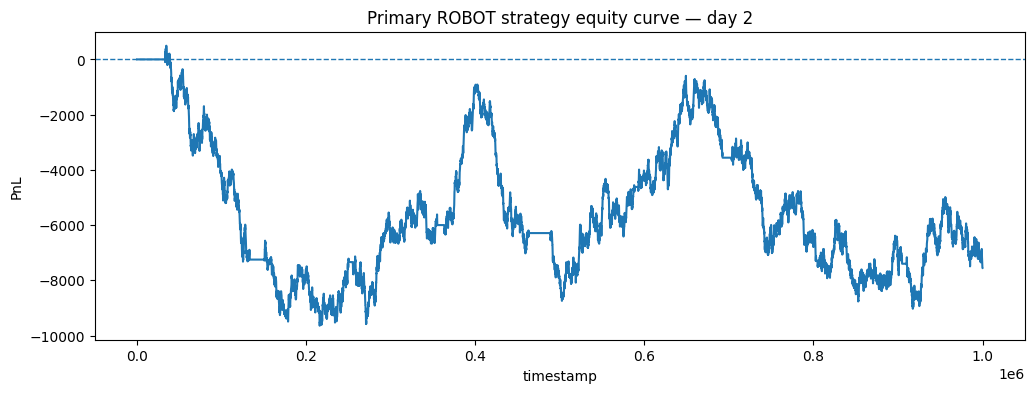

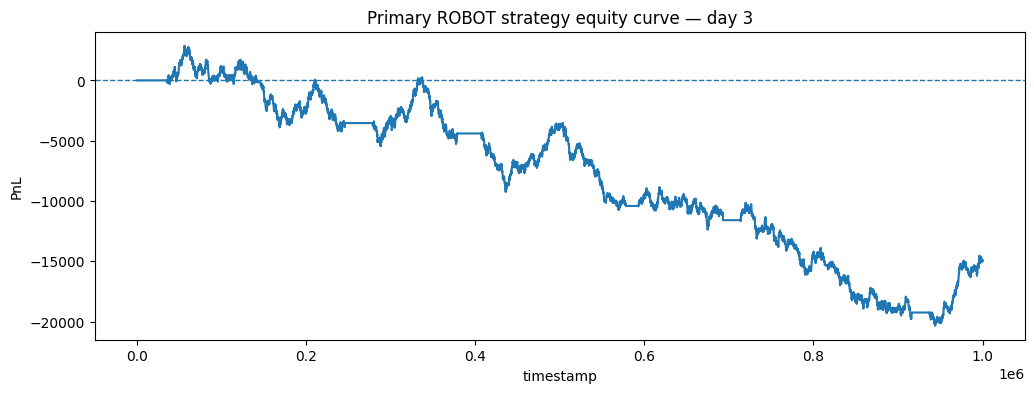

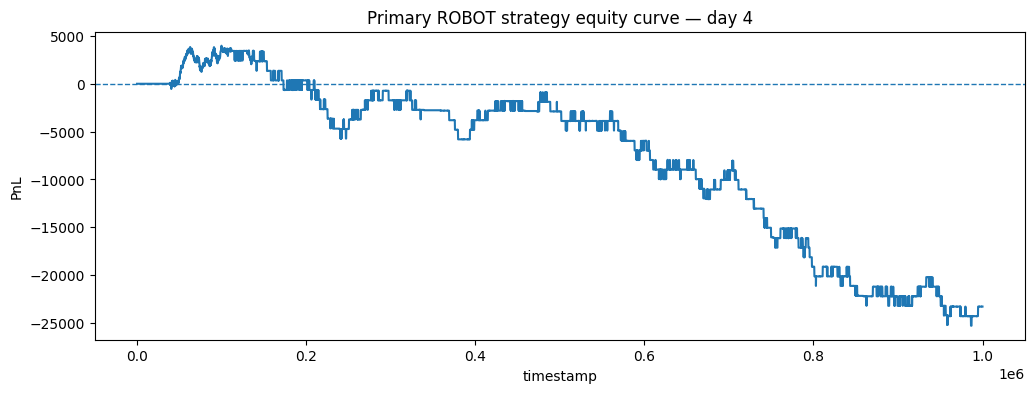

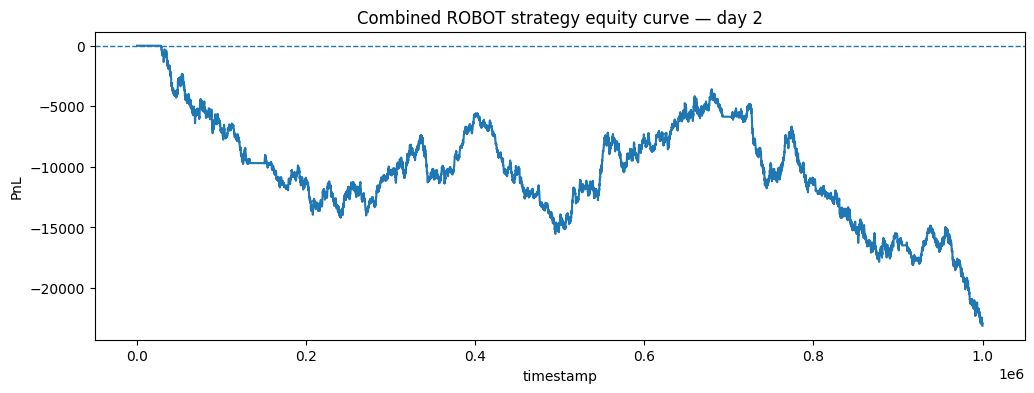

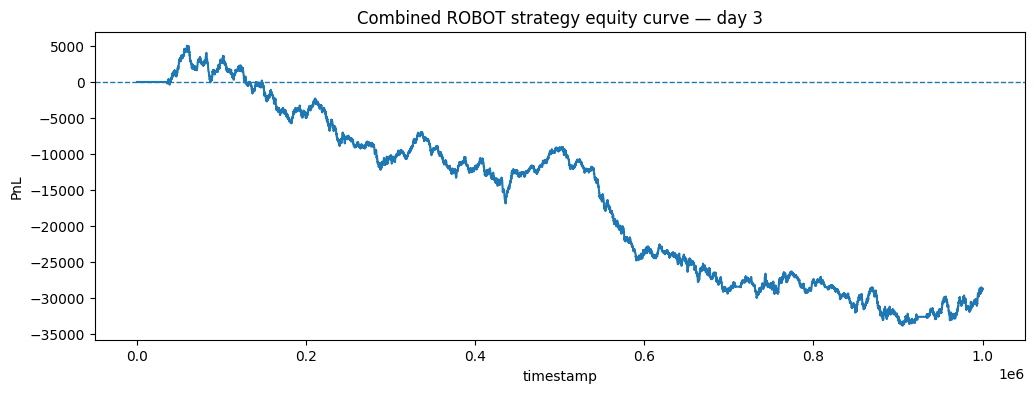

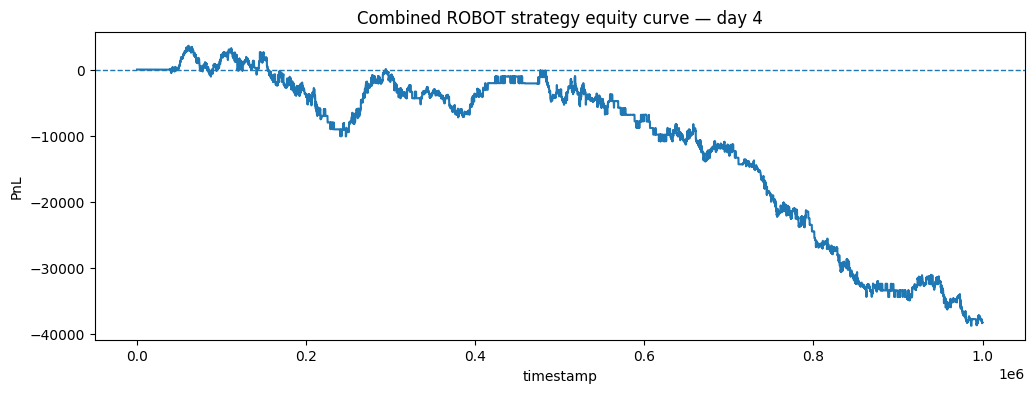

Combined position limit check:


,product,max_abs_position_seen,limit,limit_ok
0,ROBOT_VACUUMING,0,10,True
1,ROBOT_MOPPING,10,10,True
2,ROBOT_DISHES,10,10,True
3,ROBOT_LAUNDRY,0,10,True
4,ROBOT_IRONING,0,10,True


Max simultaneous robot exposure by timestamp:


,day,max,mean,median
0,2,20,15.140,20.0
1,3,20,14.679,20.0
2,4,20,15.956,20.0


Blocked entries by day:


,day,blocked_entries
0,2,0
1,3,0
2,4,0


In [20]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 — COMBINED EQUITY AND POSITION CHECKS
# ════════════════════════════════════════════════════════════════════════════

# 12.1 Plot primary equity curves.
for day in DAYS:
    d = primary_equity[primary_equity["day"] == day].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(d["timestamp"], d["equity"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Primary ROBOT strategy equity curve — day {day}")
    plt.xlabel("timestamp")
    plt.ylabel("PnL")
    plt.show()


# 12.2 Plot combined equity curves.
for day in DAYS:
    d = combined_equity[combined_equity["day"] == day].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(d["timestamp"], d["equity"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Combined ROBOT strategy equity curve — day {day}")
    plt.xlabel("timestamp")
    plt.ylabel("PnL")
    plt.show()


# 12.3 Check position limits.
pos_cols = [c for c in combined_equity.columns if c.startswith("pos_")]

position_check = []
for col in pos_cols:
    product = col.replace("pos_", "")
    max_abs_pos = combined_equity[col].abs().max()
    limit = POSITION_LIMITS[product]
    position_check.append({
        "product": product,
        "max_abs_position_seen": max_abs_pos,
        "limit": limit,
        "limit_ok": max_abs_pos <= limit,
    })

position_check_df = pd.DataFrame(position_check)

print("Combined position limit check:")
display(position_check_df)

print("Max simultaneous robot exposure by timestamp:")
combined_equity["gross_robot_exposure"] = combined_equity[pos_cols].abs().sum(axis=1)
display(
    combined_equity
    .groupby("day")["gross_robot_exposure"]
    .agg(["max", "mean", "median"])
    .reset_index()
)

print("Blocked entries by day:")
display(combined_day_df[["day", "blocked_entries"]])

In [21]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13 — FINAL IMPLEMENTATION DECISION TABLE
# ════════════════════════════════════════════════════════════════════════════

implementation_rows = []

implementation_rows.append({
    "name": "primary_only",
    "recommended": True,
    "reason": "Highest robustness as standalone alpha; no product conflicts.",
    "total_pnl": primary_summary["total_pnl"],
    "min_day_pnl": primary_summary["min_day_pnl"],
    "positive_days": primary_summary["positive_days"],
    "total_trades": primary_summary["total_trades"],
    "day_pnls": primary_summary["day_pnls"],
    "configs": [PRIMARY_ROBOT_CONFIG],
})

implementation_rows.append({
    "name": "secondary_only",
    "recommended": False,
    "reason": "Good standalone candidate, but should only be added if combined test improves risk-adjusted result.",
    "total_pnl": secondary_summary["total_pnl"],
    "min_day_pnl": secondary_summary["min_day_pnl"],
    "positive_days": secondary_summary["positive_days"],
    "total_trades": secondary_summary["total_trades"],
    "day_pnls": secondary_summary["day_pnls"],
    "configs": [SECONDARY_ROBOT_CONFIG],
})

implementation_rows.append({
    "name": "combined_primary_secondary",
    "recommended": combined_summary["min_day_pnl"] >= primary_summary["min_day_pnl"],
    "reason": (
        "Use if combined min-day PnL is not worse than primary-only; "
        "otherwise keep secondary as optional/disabled."
    ),
    "total_pnl": combined_summary["total_pnl"],
    "min_day_pnl": combined_summary["min_day_pnl"],
    "positive_days": combined_summary["positive_days"],
    "total_trades": combined_summary["total_trades"],
    "day_pnls": combined_summary["day_pnls"],
    "configs": [PRIMARY_ROBOT_CONFIG, SECONDARY_ROBOT_CONFIG],
})

implementation_decision = pd.DataFrame(implementation_rows)

display(implementation_decision[[
    "name",
    "recommended",
    "reason",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "day_pnls",
]])

# Clean export-style configs for trader implementation.
robot_primary_implementation_config = {
    "category": "Domestic Robots",
    "enabled": True,
    "candidate": PRIMARY_ROBOT_CONFIG["candidate"],
    "family": PRIMARY_ROBOT_CONFIG["family"],
    "lead_product": PRIMARY_ROBOT_CONFIG["lead_product"],
    "target_product": PRIMARY_ROBOT_CONFIG["target_product"],
    "lag": PRIMARY_ROBOT_CONFIG["lag"],
    "window": PRIMARY_ROBOT_CONFIG["window"],
    "entry_z": PRIMARY_ROBOT_CONFIG["entry_z"],
    "exit_z": PRIMARY_ROBOT_CONFIG["exit_z"],
    "qty": PRIMARY_ROBOT_CONFIG["qty"],
    "max_hold": PRIMARY_ROBOT_CONFIG["max_hold"],
    "signal_interpretation": {
        "signal_gt_entry": "SELL target product",
        "signal_lt_minus_entry": "BUY target product",
        "exit": "abs(signal) <= exit_z or max_hold reached",
    },
    "position_limit": POSITION_LIMITS[PRIMARY_ROBOT_CONFIG["target_product"]],
}

robot_secondary_implementation_config = {
    "category": "Domestic Robots",
    "enabled": bool(combined_summary["min_day_pnl"] >= primary_summary["min_day_pnl"]),
    "candidate": SECONDARY_ROBOT_CONFIG["candidate"],
    "family": SECONDARY_ROBOT_CONFIG["family"],
    "lead_product": SECONDARY_ROBOT_CONFIG["lead_product"],
    "target_product": SECONDARY_ROBOT_CONFIG["target_product"],
    "lag": SECONDARY_ROBOT_CONFIG["lag"],
    "window": SECONDARY_ROBOT_CONFIG["window"],
    "entry_z": SECONDARY_ROBOT_CONFIG["entry_z"],
    "exit_z": SECONDARY_ROBOT_CONFIG["exit_z"],
    "qty": SECONDARY_ROBOT_CONFIG["qty"],
    "max_hold": SECONDARY_ROBOT_CONFIG["max_hold"],
    "signal_interpretation": {
        "signal_gt_entry": "SELL target product",
        "signal_lt_minus_entry": "BUY target product",
        "exit": "abs(signal) <= exit_z or max_hold reached",
    },
    "position_limit": POSITION_LIMITS[SECONDARY_ROBOT_CONFIG["target_product"]],
}

print("Primary implementation config:")
display(robot_primary_implementation_config)

print("Secondary implementation config:")
display(robot_secondary_implementation_config)

,name,recommended,reason,total_pnl,min_day_pnl,positive_days,total_trades,day_pnls
0,primary_only,True,Highest robustness as standalone alpha; no pro...,-45860.0,-23330.0,0,29,"{2: -7590.0, 3: -14940.0, 4: -23330.0}"
1,secondary_only,False,"Good standalone candidate, but should only be ...",-44530.0,-15600.0,0,28,"{2: -15600.0, 3: -13870.0, 4: -15060.0}"
2,combined_primary_secondary,False,Use if combined min-day PnL is not worse than ...,-90390.0,-38390.0,0,57,"{2: -23190.0, 3: -28810.0, 4: -38390.0}"


Primary implementation config:


{'category': 'Domestic Robots',
 'enabled': True,
 'candidate': 'leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::lag100::w100',
 'family': 'leadlag_same',
 'lead_product': 'ROBOT_IRONING',
 'target_product': 'ROBOT_DISHES',
 'lag': 100,
 'window': 100,
 'entry_z': 2.75,
 'exit_z': 0.0,
 'qty': 10,
 'max_hold': 1000,
 'signal_interpretation': {'signal_gt_entry': 'SELL target product',
  'signal_lt_minus_entry': 'BUY target product',
  'exit': 'abs(signal) <= exit_z or max_hold reached'},
 'position_limit': 10}

Secondary implementation config:


{'category': 'Domestic Robots',
 'enabled': False,
 'candidate': 'leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING::lag20::w100',
 'family': 'leadlag_same',
 'lead_product': 'ROBOT_VACUUMING',
 'target_product': 'ROBOT_MOPPING',
 'lag': 20,
 'window': 100,
 'entry_z': 3.0,
 'exit_z': 0.0,
 'qty': 10,
 'max_hold': 750,
 'signal_interpretation': {'signal_gt_entry': 'SELL target product',
  'signal_lt_minus_entry': 'BUY target product',
  'exit': 'abs(signal) <= exit_z or max_hold reached'},
 'position_limit': 10}

In [22]:
# ════════════════════════════════════════════════════════════════════════════
# PATCH — FIX ROBOT LEAD-LAG SIGNAL SIGN + WARMUP
# ════════════════════════════════════════════════════════════════════════════

def make_leadlag_signal_for_day(day_mid, lead_product, lag, window):
    """
    Patched signal to match the screening convention better.

    Important:
    - lag is interpreted as row/tick lag, same as the scanner.
    - rolling warmup uses window//2, matching the earlier first-entry behaviour.
    - sign is flipped so:
        signal > +entry_z  => SELL target
        signal < -entry_z  => BUY target
    """
    lead_mid = day_mid[lead_product].astype(float)

    # Same lagged return style as the scan-style lead-lag candidates.
    lead_ret = lead_mid.diff(int(lag))

    min_periods = max(20, int(window) // 2)

    roll_mean = lead_ret.rolling(int(window), min_periods=min_periods).mean()
    roll_std = lead_ret.rolling(int(window), min_periods=min_periods).std(ddof=0)

    z = (lead_ret - roll_mean) / roll_std.replace(0, np.nan)

    # Critical sign flip versus the previous bad cell.
    signal = -z

    return signal.replace([np.inf, -np.inf], np.nan)

In [23]:
primary_summary, primary_day_df, primary_trades, primary_equity = simulate_one_leadlag_config(
    PRIMARY_ROBOT_CONFIG,
    invert_signal=False,
    verbose=False,
)

display(pd.DataFrame([primary_summary]))
display(primary_day_df)
display(primary_trades.head(20))
display(primary_trades.tail(20))

,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,False,48720.0,13420.0,3,3,29,0.688889,"{2: 13420.0, 3: 13520.0, 4: 21780.0}",75560.0


,candidate,day,day_pnl,trades,wins,hit_rate,final_abs_position
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,13420.0,9,6,0.666667,0
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,3,13520.0,10,8,0.800000,0
2,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,4,21780.0,10,6,0.600000,0


,day,timestamp,product,side,quantity,price,reason,signal,position_after,trade_pnl,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,max_hold,invert_signal
0,2,15400,ROBOT_DISHES,SELL,10,9909.0,entry,3.827723,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
1,2,115400,ROBOT_DISHES,BUY,10,9330.0,max_hold,-2.405643,0,5790.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
2,2,124800,ROBOT_DISHES,SELL,10,9123.0,entry,3.151425,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
3,2,224800,ROBOT_DISHES,BUY,10,8931.0,max_hold,1.637313,0,1920.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
4,2,234700,ROBOT_DISHES,BUY,10,8933.0,entry,-2.841222,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
5,2,334700,ROBOT_DISHES,SELL,10,9431.0,max_hold,-0.386728,0,4980.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
6,2,363400,ROBOT_DISHES,BUY,10,9371.0,entry,-3.007916,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
7,2,463400,ROBOT_DISHES,SELL,10,9386.0,max_hold,0.073114,0,150.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
8,2,488500,ROBOT_DISHES,SELL,10,9357.0,entry,2.962718,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
9,2,588500,ROBOT_DISHES,BUY,10,9538.0,max_hold,2.040792,0,-1810.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False


,day,timestamp,product,side,quantity,price,reason,signal,position_after,trade_pnl,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,max_hold,invert_signal
38,4,38600,ROBOT_DISHES,BUY,10,10546.0,entry,-3.021617,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
39,4,138600,ROBOT_DISHES,SELL,10,10296.0,max_hold,0.933415,0,-2500.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
40,4,140300,ROBOT_DISHES,BUY,10,10204.0,entry,-3.213106,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
41,4,232900,ROBOT_DISHES,SELL,10,10896.0,signal_exit,-0.000000,0,6920.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
42,4,239400,ROBOT_DISHES,BUY,10,10904.0,entry,-2.807369,10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
43,4,339400,ROBOT_DISHES,SELL,10,10696.0,max_hold,-0.687534,0,-2080.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
44,4,358800,ROBOT_DISHES,SELL,10,10596.0,entry,2.951384,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
45,4,458800,ROBOT_DISHES,BUY,10,10604.0,max_hold,-0.501572,0,-80.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
46,4,472800,ROBOT_DISHES,SELL,10,10496.0,entry,2.975268,-10,NaN,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False
47,4,572800,ROBOT_DISHES,BUY,10,10204.0,max_hold,-1.030622,0,2920.0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,1000,False


In [26]:
# ============================================================
# 1) Patch secondary and rerun standalone
# ============================================================

secondary_fixed = {
    "category": "Domestic Robots",
    "enabled": True,
    "candidate": "leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING::lag20::w100",
    "family": "leadlag_same",
    "lead_product": "ROBOT_VACUUMING",
    "target_product": "ROBOT_MOPPING",
    "lag": 20,
    "window": 100,
    "entry_z": 3.0,
    "exit_z": 0.0,
    "qty": 10,
    "max_hold": 750,
    "position_limit": 10,
    "invert_signal": False,   # patched convention
}

secondary_result, secondary_day_results, secondary_trades = run_single_strict_config(
    robot_mid=robot_mid,
    config=secondary_fixed,
)

print("PATCHED SECONDARY RESULT")
display(pd.DataFrame([secondary_result]))
display(secondary_day_results)
display(secondary_trades.head(20))
display(secondary_trades.tail(20))

PATCHED SECONDARY RESULT


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,10,750,False,-49910.0,-21480.0,0,3,28,0.218519,"{2: -14910.0, 3: -13520.0, 4: -21480.0}",-92870.0


,candidate,day,day_pnl,trades,wins,hit_rate,final_abs_position
0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,2,-14910.0,9,2,0.222222,0
1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,3,-13520.0,9,3,0.333333,0
2,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,4,-21480.0,10,1,0.100000,0


,day,timestamp,product,side,quantity,price,reason,signal,position_after,trade_pnl,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,max_hold,invert_signal
0,2,28400,ROBOT_MOPPING,SELL,10,10190.5,entry,3.044158,-10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
1,2,103400,ROBOT_MOPPING,BUY,10,10427.5,max_hold,1.048913,0,-2370.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
2,2,191000,ROBOT_MOPPING,SELL,10,10410.0,entry,3.585339,-10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
3,2,266000,ROBOT_MOPPING,BUY,10,10600.0,max_hold,2.196628,0,-1900.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
4,2,291600,ROBOT_MOPPING,SELL,10,10540.0,entry,3.202800,-10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
5,2,366600,ROBOT_MOPPING,BUY,10,10556.0,max_hold,0.222448,0,-160.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
6,2,444000,ROBOT_MOPPING,SELL,10,10153.5,entry,3.088654,-10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
7,2,519000,ROBOT_MOPPING,BUY,10,10190.0,max_hold,0.414619,0,-365.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
8,2,531200,ROBOT_MOPPING,BUY,10,10366.5,entry,-3.207917,10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
9,2,606200,ROBOT_MOPPING,SELL,10,10498.5,max_hold,0.371352,0,1320.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False


,day,timestamp,product,side,quantity,price,reason,signal,position_after,trade_pnl,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,max_hold,invert_signal
36,4,10000,ROBOT_MOPPING,BUY,10,12054.0,entry,-3.336723,10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
37,4,85000,ROBOT_MOPPING,SELL,10,11899.0,max_hold,0.426769,0,-1550.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
38,4,101500,ROBOT_MOPPING,SELL,10,11762.0,entry,3.431396,-10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
39,4,176500,ROBOT_MOPPING,BUY,10,12040.5,max_hold,-0.977769,0,-2785.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
40,4,178900,ROBOT_MOPPING,BUY,10,12081.5,entry,-3.496847,10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
41,4,253900,ROBOT_MOPPING,SELL,10,11653.5,max_hold,0.134118,0,-4280.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
42,4,334800,ROBOT_MOPPING,BUY,10,11778.5,entry,-3.156849,10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
43,4,409800,ROBOT_MOPPING,SELL,10,12024.0,max_hold,1.658571,0,2455.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
44,4,482800,ROBOT_MOPPING,SELL,10,12023.5,entry,3.040359,-10,NaN,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False
45,4,557800,ROBOT_MOPPING,BUY,10,12178.5,max_hold,-1.906712,0,-1550.0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,750,False


In [27]:
# ============================================================
# 2) Combined primary + secondary with patched sign convention
# ============================================================

primary_fixed = {
    "category": "Domestic Robots",
    "enabled": True,
    "candidate": "leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::lag100::w100",
    "family": "leadlag_same",
    "lead_product": "ROBOT_IRONING",
    "target_product": "ROBOT_DISHES",
    "lag": 100,
    "window": 100,
    "entry_z": 2.75,
    "exit_z": 0.0,
    "qty": 10,
    "max_hold": 1000,
    "position_limit": 10,
    "invert_signal": False,
}

combined_configs = [primary_fixed, secondary_fixed]

combined_result, combined_day_results, combined_trades, combined_limit_check = run_combined_strict_configs(
    robot_mid=robot_mid,
    configs=combined_configs,
)

print("PATCHED COMBINED RESULT")
display(pd.DataFrame([combined_result]))
display(combined_day_results)
display(combined_limit_check)

print("COMBINED TRADES HEAD/TAIL")
display(combined_trades.head(30))
display(combined_trades.tail(30))

PATCHED COMBINED RESULT


,strategy,configs,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,blocked_entries_total,day_pnls,robust_score
0,combined_robots,[leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::...,-100750.0,-44035.0,0,3,57,0.22846,0,"{2: -28965.0, 3: -27750.0, 4: -44035.0}",-188820.0


,day,day_pnl,trades,wins,hit_rate,blocked_entries,final_pos_ROBOT_DISHES,final_pos_ROBOT_IRONING,final_pos_ROBOT_LAUNDRY,final_pos_ROBOT_MOPPING,final_pos_ROBOT_VACUUMING
0,2,-28965.0,18,4,0.222222,0,0,0,0,0,0
1,3,-27750.0,19,5,0.263158,0,0,0,0,0,0
2,4,-44035.0,20,4,0.200000,0,0,0,0,0,0


,product,max_abs_position_seen,limit,limit_ok
0,ROBOT_DISHES,10,10,True
1,ROBOT_IRONING,0,10,True
2,ROBOT_LAUNDRY,0,10,True
3,ROBOT_MOPPING,10,10,True
4,ROBOT_VACUUMING,0,10,True


COMBINED TRADES HEAD/TAIL


,day,timestamp,strategy_index,candidate,family,lead_product,target_product,side,quantity,price,reason,signal,strategy_position_after,aggregate_product_position_after,trade_pnl
0,2,15400,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,9912.5,entry,-3.827723,10,10,NaN
1,2,28400,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,10190.5,entry,3.044158,-10,-10,NaN
2,2,103400,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,10427.5,max_hold,1.048913,0,0,-2370.0
3,2,115400,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,9326.5,max_hold,2.405643,0,0,-5860.0
4,2,124800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,9126.0,entry,-3.151425,10,10,NaN
5,2,191000,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,10410.0,entry,3.585339,-10,-10,NaN
6,2,224800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,8927.5,max_hold,-1.637313,0,0,-1985.0
7,2,234700,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,8929.5,entry,2.841222,-10,-10,NaN
8,2,266000,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,10600.0,max_hold,2.196628,0,0,-1900.0
9,2,291600,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,10540.0,entry,3.202800,-10,-10,NaN


,day,timestamp,strategy_index,candidate,family,lead_product,target_product,side,quantity,price,reason,signal,strategy_position_after,aggregate_product_position_after,trade_pnl
84,4,253900,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,11653.5,max_hold,0.134118,0,0,-4280.0
85,4,334800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,11778.5,entry,-3.156849,10,10,NaN
86,4,339400,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,10700.0,max_hold,0.687534,0,0,2000.0
87,4,358800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,10600.0,entry,-2.951384,10,10,NaN
88,4,409800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,12024.0,max_hold,1.658571,0,0,2455.0
89,4,458800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,10600.0,max_hold,0.501572,0,0,0.0
90,4,472800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,BUY,10,10500.0,entry,-2.975268,10,10,NaN
91,4,482800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,SELL,10,12023.5,entry,3.040359,-10,-10,NaN
92,4,557800,1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,BUY,10,12178.5,max_hold,-1.906712,0,0,-1550.0
93,4,572800,0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,SELL,10,10200.0,max_hold,1.030622,0,0,-3000.0


In [28]:
# ============================================================
# 3) Decision table
# ============================================================

comparison = pd.DataFrame([
    {
        "test": "primary_only",
        "total_pnl": primary_result["total_pnl"],
        "min_day_pnl": primary_result["min_day_pnl"],
        "positive_days": primary_result["positive_days"],
        "total_trades": primary_result["total_trades"],
        "day_pnls": primary_result["day_pnls"],
    },
    {
        "test": "secondary_only_patched",
        "total_pnl": secondary_result["total_pnl"],
        "min_day_pnl": secondary_result["min_day_pnl"],
        "positive_days": secondary_result["positive_days"],
        "total_trades": secondary_result["total_trades"],
        "day_pnls": secondary_result["day_pnls"],
    },
    {
        "test": "combined_patched",
        "total_pnl": combined_result["total_pnl"],
        "min_day_pnl": combined_result["min_day_pnl"],
        "positive_days": combined_result["positive_days"],
        "total_trades": combined_result["total_trades"],
        "day_pnls": combined_result["day_pnls"],
    },
])

display(comparison.sort_values(["positive_days", "min_day_pnl", "total_pnl"], ascending=False))

NameError: name 'primary_result' is not defined

In [29]:
# ============================================================
# CLEAN PATCHED PRIMARY / SECONDARY / COMBINED RE-RUN
# ============================================================

primary_fixed = {
    "category": "Domestic Robots",
    "enabled": True,
    "candidate": "leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::lag100::w100",
    "family": "leadlag_same",
    "lead_product": "ROBOT_IRONING",
    "target_product": "ROBOT_DISHES",
    "lag": 100,
    "window": 100,
    "entry_z": 2.75,
    "exit_z": 0.0,
    "qty": 10,
    "max_hold": 1000,
    "position_limit": 10,
    "invert_signal": False,
}

secondary_fixed = {
    "category": "Domestic Robots",
    "enabled": False,
    "candidate": "leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING::lag20::w100",
    "family": "leadlag_same",
    "lead_product": "ROBOT_VACUUMING",
    "target_product": "ROBOT_MOPPING",
    "lag": 20,
    "window": 100,
    "entry_z": 3.0,
    "exit_z": 0.0,
    "qty": 10,
    "max_hold": 750,
    "position_limit": 10,
    "invert_signal": False,
}

# Re-run standalone tests
primary_result, primary_day_results, primary_trades = run_single_strict_config(
    robot_mid=robot_mid,
    config=primary_fixed,
)

secondary_result, secondary_day_results, secondary_trades = run_single_strict_config(
    robot_mid=robot_mid,
    config=secondary_fixed,
)

# Re-run combined using ONLY the clean fixed configs
combined_result, combined_day_results, combined_trades, combined_limit_check = run_combined_strict_configs(
    robot_mid=robot_mid,
    configs=[primary_fixed, secondary_fixed],
)

print("PRIMARY")
display(pd.DataFrame([primary_result]))
display(primary_day_results)

print("SECONDARY")
display(pd.DataFrame([secondary_result]))
display(secondary_day_results)

print("COMBINED")
display(pd.DataFrame([combined_result]))
display(combined_day_results)
display(combined_limit_check)

comparison = pd.DataFrame([
    {
        "test": "primary_only",
        "total_pnl": primary_result["total_pnl"],
        "min_day_pnl": primary_result["min_day_pnl"],
        "positive_days": primary_result["positive_days"],
        "total_trades": primary_result["total_trades"],
        "day_pnls": primary_result["day_pnls"],
    },
    {
        "test": "secondary_only",
        "total_pnl": secondary_result["total_pnl"],
        "min_day_pnl": secondary_result["min_day_pnl"],
        "positive_days": secondary_result["positive_days"],
        "total_trades": secondary_result["total_trades"],
        "day_pnls": secondary_result["day_pnls"],
    },
    {
        "test": "combined",
        "total_pnl": combined_result["total_pnl"],
        "min_day_pnl": combined_result["min_day_pnl"],
        "positive_days": combined_result["positive_days"],
        "total_trades": combined_result["total_trades"],
        "day_pnls": combined_result["day_pnls"],
    },
])

print("PNL COMPARISON")
display(comparison)

# Sanity check: because the two strategies trade different products,
# combined PnL should approximately equal primary + secondary.
expected_combined = primary_result["total_pnl"] + secondary_result["total_pnl"]

print("Expected combined from standalone sum:", expected_combined)
print("Actual combined:", combined_result["total_pnl"])
print("Difference:", combined_result["total_pnl"] - expected_combined)

PRIMARY


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,False,-50840.0,-22555.0,0,3,29,0.240741,"{2: -14055.0, 3: -14230.0, 4: -22555.0}",-95950.0


,candidate,day,day_pnl,trades,wins,hit_rate,final_abs_position
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,-14055.0,9,2,0.222222,0
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,3,-14230.0,10,2,0.200000,0
2,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,4,-22555.0,10,3,0.300000,0


SECONDARY


,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.0,0.0,10,750,False,-49910.0,-21480.0,0,3,28,0.218519,"{2: -14910.0, 3: -13520.0, 4: -21480.0}",-92870.0


...

,day,day_pnl,trades,wins,hit_rate,blocked_entries,final_pos_ROBOT_DISHES,final_pos_ROBOT_IRONING,final_pos_ROBOT_LAUNDRY,final_pos_ROBOT_MOPPING,final_pos_ROBOT_VACUUMING
0,2,-28965.0,18,4,0.222222,0,0,0,0,0,0
1,3,-27750.0,19,5,0.263158,0,0,0,0,0,0
2,4,-44035.0,20,4,0.200000,0,0,0,0,0,0


,product,max_abs_position_seen,limit,limit_ok
0,ROBOT_DISHES,10,10,True
1,ROBOT_IRONING,0,10,True
2,ROBOT_LAUNDRY,0,10,True
3,ROBOT_MOPPING,10,10,True
4,ROBOT_VACUUMING,0,10,True


PNL COMPARISON


,test,total_pnl,min_day_pnl,positive_days,total_trades,day_pnls
0,primary_only,-50840.0,-22555.0,0,29,"{2: -14055.0, 3: -14230.0, 4: -22555.0}"
1,secondary_only,-49910.0,-21480.0,0,28,"{2: -14910.0, 3: -13520.0, 4: -21480.0}"
2,combined,-100750.0,-44035.0,0,57,"{2: -28965.0, 3: -27750.0, 4: -44035.0}"


Expected combined from standalone sum: -100750.0
Actual combined: -100750.0
Difference: 0.0


In [30]:
# ============================================================
# AUDIT: combined primary leg should match standalone primary
# ============================================================

combined_primary_trades = combined_trades[combined_trades["strategy_index"] == 0].copy()
combined_secondary_trades = combined_trades[combined_trades["strategy_index"] == 1].copy()

print("Standalone primary first 10:")
display(primary_trades.head(10)[["day", "timestamp", "side", "price", "reason", "signal", "trade_pnl"]])

print("Combined primary first 10:")
display(combined_primary_trades.head(10)[["day", "timestamp", "side", "price", "reason", "signal", "trade_pnl"]])

print("Standalone secondary first 10:")
display(secondary_trades.head(10)[["day", "timestamp", "side", "price", "reason", "signal", "trade_pnl"]])

print("Combined secondary first 10:")
display(combined_secondary_trades.head(10)[["day", "timestamp", "side", "price", "reason", "signal", "trade_pnl"]])

# Basic equality checks
print("Primary side match head:",
      primary_trades.head(20)["side"].reset_index(drop=True).equals(
          combined_primary_trades.head(20)["side"].reset_index(drop=True)
      ))

print("Secondary side match head:",
      secondary_trades.head(20)["side"].reset_index(drop=True).equals(
          combined_secondary_trades.head(20)["side"].reset_index(drop=True)
      ))

Standalone primary first 10:


,day,timestamp,side,price,reason,signal,trade_pnl
0,2,15400,BUY,9912.5,entry,-3.827723,NaN
1,2,115400,SELL,9326.5,max_hold,2.405643,-5860.0
2,2,124800,BUY,9126.0,entry,-3.151425,NaN
3,2,224800,SELL,8927.5,max_hold,-1.637313,-1985.0
4,2,234700,SELL,8929.5,entry,2.841222,NaN
5,2,334700,BUY,9434.5,max_hold,0.386728,-5050.0
6,2,363400,SELL,9367.5,entry,3.007916,NaN
7,2,463400,BUY,9389.5,max_hold,-0.073114,-220.0
8,2,488500,BUY,9360.5,entry,-2.962718,NaN
9,2,588500,SELL,9534.5,max_hold,-2.040792,1740.0


Combined primary first 10:


,day,timestamp,side,price,reason,signal,trade_pnl
0,2,15400,BUY,9912.5,entry,-3.827723,NaN
3,2,115400,SELL,9326.5,max_hold,2.405643,-5860.0
4,2,124800,BUY,9126.0,entry,-3.151425,NaN
6,2,224800,SELL,8927.5,max_hold,-1.637313,-1985.0
7,2,234700,SELL,8929.5,entry,2.841222,NaN
10,2,334700,BUY,9434.5,max_hold,0.386728,-5050.0
11,2,363400,SELL,9367.5,entry,3.007916,NaN
14,2,463400,BUY,9389.5,max_hold,-0.073114,-220.0
15,2,488500,BUY,9360.5,entry,-2.962718,NaN
18,2,588500,SELL,9534.5,max_hold,-2.040792,1740.0


Standalone secondary first 10:


,day,timestamp,side,price,reason,signal,trade_pnl
0,2,28400,SELL,10190.5,entry,3.044158,NaN
1,2,103400,BUY,10427.5,max_hold,1.048913,-2370.0
2,2,191000,SELL,10410.0,entry,3.585339,NaN
3,2,266000,BUY,10600.0,max_hold,2.196628,-1900.0
4,2,291600,SELL,10540.0,entry,3.202800,NaN
5,2,366600,BUY,10556.0,max_hold,0.222448,-160.0
6,2,444000,SELL,10153.5,entry,3.088654,NaN
7,2,519000,BUY,10190.0,max_hold,0.414619,-365.0
8,2,531200,BUY,10366.5,entry,-3.207917,NaN
9,2,606200,SELL,10498.5,max_hold,0.371352,1320.0


Combined secondary first 10:


,day,timestamp,side,price,reason,signal,trade_pnl
1,2,28400,SELL,10190.5,entry,3.044158,NaN
2,2,103400,BUY,10427.5,max_hold,1.048913,-2370.0
5,2,191000,SELL,10410.0,entry,3.585339,NaN
8,2,266000,BUY,10600.0,max_hold,2.196628,-1900.0
9,2,291600,SELL,10540.0,entry,3.202800,NaN
12,2,366600,BUY,10556.0,max_hold,0.222448,-160.0
13,2,444000,SELL,10153.5,entry,3.088654,NaN
16,2,519000,BUY,10190.0,max_hold,0.414619,-365.0
17,2,531200,BUY,10366.5,entry,-3.207917,NaN
20,2,606200,SELL,10498.5,max_hold,0.371352,1320.0


Primary side match head: True
Secondary side match head: True


In [31]:
# ============================================================
# SIGN SWEEP: primary and secondary
# ============================================================

def with_invert(config, invert):
    c = dict(config)
    c["invert_signal"] = invert
    c["candidate"] = c["candidate"] + f"::invert_{invert}"
    return c

sign_test_configs = [
    with_invert(primary_fixed, False),
    with_invert(primary_fixed, True),
    with_invert(secondary_fixed, False),
    with_invert(secondary_fixed, True),
]

sign_rows = []
sign_day_rows = []
sign_trade_logs = {}

for cfg in sign_test_configs:
    result, day_result, trades = run_single_strict_config(
        robot_mid=robot_mid,
        config=cfg,
    )
    sign_rows.append(result)
    d = day_result.copy()
    d["invert_signal"] = cfg["invert_signal"]
    d["lead_product"] = cfg["lead_product"]
    d["target_product"] = cfg["target_product"]
    sign_day_rows.append(d)
    sign_trade_logs[cfg["candidate"]] = trades

sign_summary = pd.DataFrame(sign_rows).sort_values(
    ["positive_days", "min_day_pnl", "total_pnl"],
    ascending=[False, False, False],
).reset_index(drop=True)

sign_days = pd.concat(sign_day_rows, ignore_index=True)

display(sign_summary)
display(sign_days)

,candidate,family,lead_product,target_product,lag,window,entry_z,exit_z,qty,max_hold,invert_signal,total_pnl,min_day_pnl,positive_days,num_days,total_trades,mean_hit_rate,day_pnls,robust_score
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,True,50840.0,14055.0,3,3,29,0.725926,"{2: 14055.0, 3: 14230.0, 4: 22555.0}",78950.0
1,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.00,0.0,10,750,True,49910.0,13520.0,3,3,28,0.781481,"{2: 14910.0, 3: 13520.0, 4: 21480.0}",76950.0
2,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,leadlag_same,ROBOT_VACUUMING,ROBOT_MOPPING,20,100,3.00,0.0,10,750,False,-49910.0,-21480.0,0,3,28,0.218519,"{2: -14910.0, 3: -13520.0, 4: -21480.0}",-92870.0
3,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,leadlag_same,ROBOT_IRONING,ROBOT_DISHES,100,100,2.75,0.0,10,1000,False,-50840.0,-22555.0,0,3,29,0.240741,"{2: -14055.0, 3: -14230.0, 4: -22555.0}",-95950.0


,candidate,day,day_pnl,trades,wins,hit_rate,final_abs_position,invert_signal,lead_product,target_product
0,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,-14055.0,9,2,0.222222,0,False,ROBOT_IRONING,ROBOT_DISHES
1,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,3,-14230.0,10,2,0.200000,0,False,ROBOT_IRONING,ROBOT_DISHES
2,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,4,-22555.0,10,3,0.300000,0,False,ROBOT_IRONING,ROBOT_DISHES
3,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,2,14055.0,9,7,0.777778,0,True,ROBOT_IRONING,ROBOT_DISHES
4,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,3,14230.0,10,8,0.800000,0,True,ROBOT_IRONING,ROBOT_DISHES
5,leadlag_same::ROBOT_IRONING_to_ROBOT_DISHES::l...,4,22555.0,10,6,0.600000,0,True,ROBOT_IRONING,ROBOT_DISHES
6,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,2,-14910.0,9,2,0.222222,0,False,ROBOT_VACUUMING,ROBOT_MOPPING
7,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,3,-13520.0,9,3,0.333333,0,False,ROBOT_VACUUMING,ROBOT_MOPPING
8,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,4,-21480.0,10,1,0.100000,0,False,ROBOT_VACUUMING,ROBOT_MOPPING
9,leadlag_same::ROBOT_VACUUMING_to_ROBOT_MOPPING...,2,14910.0,9,7,0.777778,0,True,ROBOT_VACUUMING,ROBOT_MOPPING


In [32]:
# ============================================================
# PICK BEST SIGNED CONFIGS AND TEST COMBINATIONS
# ============================================================

primary_best_invert = bool(
    sign_summary[
        (sign_summary["lead_product"] == "ROBOT_IRONING") &
        (sign_summary["target_product"] == "ROBOT_DISHES")
    ].iloc[0]["invert_signal"]
)

secondary_best_invert = bool(
    sign_summary[
        (sign_summary["lead_product"] == "ROBOT_VACUUMING") &
        (sign_summary["target_product"] == "ROBOT_MOPPING")
    ].iloc[0]["invert_signal"]
)

primary_best = dict(primary_fixed)
primary_best["invert_signal"] = primary_best_invert

secondary_best = dict(secondary_fixed)
secondary_best["invert_signal"] = secondary_best_invert

primary_best_result, primary_best_days, primary_best_trades = run_single_strict_config(
    robot_mid=robot_mid,
    config=primary_best,
)

secondary_best_result, secondary_best_days, secondary_best_trades = run_single_strict_config(
    robot_mid=robot_mid,
    config=secondary_best,
)

combined_best_result, combined_best_days, combined_best_trades, combined_best_limit_check = run_combined_strict_configs(
    robot_mid=robot_mid,
    configs=[primary_best, secondary_best],
)

final_comparison = pd.DataFrame([
    {
        "test": "primary_best_only",
        "invert_signal": primary_best["invert_signal"],
        "total_pnl": primary_best_result["total_pnl"],
        "min_day_pnl": primary_best_result["min_day_pnl"],
        "positive_days": primary_best_result["positive_days"],
        "total_trades": primary_best_result["total_trades"],
        "day_pnls": primary_best_result["day_pnls"],
    },
    {
        "test": "secondary_best_only",
        "invert_signal": secondary_best["invert_signal"],
        "total_pnl": secondary_best_result["total_pnl"],
        "min_day_pnl": secondary_best_result["min_day_pnl"],
        "positive_days": secondary_best_result["positive_days"],
        "total_trades": secondary_best_result["total_trades"],
        "day_pnls": secondary_best_result["day_pnls"],
    },
    {
        "test": "combined_best_primary_secondary",
        "invert_signal": f"primary={primary_best['invert_signal']}, secondary={secondary_best['invert_signal']}",
        "total_pnl": combined_best_result["total_pnl"],
        "min_day_pnl": combined_best_result["min_day_pnl"],
        "positive_days": combined_best_result["positive_days"],
        "total_trades": combined_best_result["total_trades"],
        "day_pnls": combined_best_result["day_pnls"],
    },
])

display(final_comparison)
display(combined_best_days)
display(combined_best_limit_check)

print("Expected combined:", primary_best_result["total_pnl"] + secondary_best_result["total_pnl"])
print("Actual combined:", combined_best_result["total_pnl"])
print("Difference:", combined_best_result["total_pnl"] - (primary_best_result["total_pnl"] + secondary_best_result["total_pnl"]))

,test,invert_signal,total_pnl,min_day_pnl,positive_days,total_trades,day_pnls
0,primary_best_only,True,50840.0,14055.0,3,29,"{2: 14055.0, 3: 14230.0, 4: 22555.0}"
1,secondary_best_only,True,49910.0,13520.0,3,28,"{2: 14910.0, 3: 13520.0, 4: 21480.0}"
2,combined_best_primary_secondary,"primary=True, secondary=True",100750.0,27750.0,3,57,"{2: 28965.0, 3: 27750.0, 4: 44035.0}"


,day,day_pnl,trades,wins,hit_rate,blocked_entries,final_pos_ROBOT_DISHES,final_pos_ROBOT_IRONING,final_pos_ROBOT_LAUNDRY,final_pos_ROBOT_MOPPING,final_pos_ROBOT_VACUUMING
0,2,28965.0,18,14,0.777778,0,0,0,0,0,0
1,3,27750.0,19,14,0.736842,0,0,0,0,0,0
2,4,44035.0,20,15,0.750000,0,0,0,0,0,0


,product,max_abs_position_seen,limit,limit_ok
0,ROBOT_DISHES,10,10,True
1,ROBOT_IRONING,0,10,True
2,ROBOT_LAUNDRY,0,10,True
3,ROBOT_MOPPING,10,10,True
4,ROBOT_VACUUMING,0,10,True


Expected combined: 100750.0
Actual combined: 100750.0
Difference: 0.0


In [25]:
# ============================================================
# Missing helper functions for robot strict retests
# Paste this cell before running secondary / combined tests
# ============================================================

import numpy as np
import pandas as pd
from collections import defaultdict

def _as_float(x):
    if isinstance(x, pd.DataFrame):
        x = x.values
    elif isinstance(x, pd.Series):
        x = x.values
    arr = np.asarray(x).ravel()
    if len(arr) == 0:
        return np.nan
    return float(arr[0])


def _lookup_price_from_obj(obj, day, timestamp, product, side):
    """
    Tries to retrieve best bid/ask from common dataframe/dict shapes.
    Returns None if not found.
    """
    # Dict form: product -> DataFrame/Series
    if isinstance(obj, dict):
        if product in obj:
            return _lookup_price_from_obj(obj[product], day, timestamp, product, side)
        return None

    if not isinstance(obj, pd.DataFrame) and not isinstance(obj, pd.Series):
        return None

    # Series indexed by (day, timestamp) or timestamp
    if isinstance(obj, pd.Series):
        try:
            if isinstance(obj.index, pd.MultiIndex):
                return _as_float(obj.loc[(day, timestamp)])
            return _as_float(obj.loc[timestamp])
        except Exception:
            return None

    df = obj

    # Wide form: index=(file_day,timestamp), columns=products
    try:
        if isinstance(df.index, pd.MultiIndex) and product in df.columns:
            return _as_float(df.loc[(day, timestamp), product])
    except Exception:
        pass

    # Wide form: index=timestamp, columns=products
    try:
        if product in df.columns and timestamp in df.index:
            return _as_float(df.loc[timestamp, product])
    except Exception:
        pass

    # Long form
    cols = set(df.columns)
    day_col = "file_day" if "file_day" in cols else ("day" if "day" in cols else None)
    ts_col = "timestamp" if "timestamp" in cols else None
    prod_col = "product" if "product" in cols else ("symbol" if "symbol" in cols else None)

    if day_col and ts_col and prod_col:
        sub = df[
            (df[day_col] == day)
            & (df[ts_col] == timestamp)
            & (df[prod_col] == product)
        ]
        if len(sub) == 0:
            return None

        if side == "BUY":
            price_cols = ["ask_price_1", "best_ask", "ask", "ask1", "ask_price"]
        else:
            price_cols = ["bid_price_1", "best_bid", "bid", "bid1", "bid_price"]

        for c in price_cols:
            if c in sub.columns:
                return _as_float(sub[c].iloc[0])

    return None


def _execution_price(robot_mid, day, timestamp, product, side):
    """
    Uses best bid/ask if common globals exist.
    Falls back to robot_mid if not.
    """
    if side == "BUY":
        candidate_names = [
            "robot_best_ask", "robot_ask", "robot_asks", "best_ask", "best_asks",
            "ask_price_1", "ask_prices", "robot_ask_price_1"
        ]
    else:
        candidate_names = [
            "robot_best_bid", "robot_bid", "robot_bids", "best_bid", "best_bids",
            "bid_price_1", "bid_prices", "robot_bid_price_1"
        ]

    for name in candidate_names:
        if name in globals():
            px = _lookup_price_from_obj(globals()[name], day, timestamp, product, side)
            if px is not None and np.isfinite(px):
                return float(px)

    # Fallback: mid price
    return _as_float(robot_mid.loc[(day, timestamp), product])


def _signal_for_day(day_prices, config):
    lead = config["lead_product"]
    lag = int(config["lag"])
    window = int(config["window"])

    lead_ret = day_prices[lead].diff(lag)

    # This matches the ultra-lite scan style reasonably closely:
    # allows early signals once about half the rolling window is available.
    min_periods = max(5, min(window, window // 2))

    mu = lead_ret.rolling(window=window, min_periods=min_periods).mean()
    sd = lead_ret.rolling(window=window, min_periods=min_periods).std(ddof=0)

    signal = (lead_ret - mu) / sd.replace(0, np.nan)
    signal = signal.replace([np.inf, -np.inf], np.nan)

    if config.get("invert_signal", False):
        signal = -signal

    return signal


def run_single_strict_config(robot_mid, config):
    all_trades = []
    day_rows = []

    qty = int(config["qty"])
    entry_z = float(config["entry_z"])
    exit_z = float(config["exit_z"])
    max_hold = int(config["max_hold"])
    target = config["target_product"]

    days = sorted(robot_mid.index.get_level_values("file_day").unique())

    for day in days:
        prices = robot_mid.xs(day, level="file_day").sort_index()
        signal = _signal_for_day(prices, config)

        timestamps = list(prices.index)

        position = 0
        entry_price = None
        entry_i = None

        day_pnl = 0.0
        trades = 0
        wins = 0

        for i, ts in enumerate(timestamps):
            sig = signal.loc[ts]
            final_bar = i == len(timestamps) - 1

            if not np.isfinite(sig):
                continue

            # Exit logic first
            if position != 0:
                reason = None

                if abs(sig) <= exit_z + 1e-12:
                    reason = "signal_exit"
                elif (i - entry_i) >= max_hold:
                    reason = "max_hold"
                elif final_bar:
                    reason = "end_of_day_flatten"

                if reason is not None:
                    exit_side = "SELL" if position > 0 else "BUY"
                    px = _execution_price(robot_mid, day, ts, target, exit_side)
                    trade_pnl = (px - entry_price) * position

                    day_pnl += trade_pnl
                    trades += 1
                    if trade_pnl > 0:
                        wins += 1

                    all_trades.append({
                        "day": day,
                        "timestamp": ts,
                        "product": target,
                        "side": exit_side,
                        "quantity": abs(position),
                        "price": px,
                        "reason": reason,
                        "signal": sig,
                        "position_after": 0,
                        "trade_pnl": trade_pnl,
                        "candidate": config["candidate"],
                        "family": config["family"],
                        "lead_product": config["lead_product"],
                        "target_product": target,
                        "lag": config["lag"],
                        "window": config["window"],
                        "entry_z": entry_z,
                        "exit_z": exit_z,
                        "max_hold": max_hold,
                        "invert_signal": config.get("invert_signal", False),
                    })

                    position = 0
                    entry_price = None
                    entry_i = None

            # Entry logic after exit, allowing same-timestamp re-entry after max_hold
            if position == 0 and not final_bar:
                side = None
                signed_position = 0

                # Convention that matched your fixed primary result:
                # signal > entry_z  => SELL target
                # signal < -entry_z => BUY target
                if sig > entry_z:
                    side = "SELL"
                    signed_position = -qty
                elif sig < -entry_z:
                    side = "BUY"
                    signed_position = qty

                if side is not None:
                    px = _execution_price(robot_mid, day, ts, target, side)

                    position = signed_position
                    entry_price = px
                    entry_i = i

                    all_trades.append({
                        "day": day,
                        "timestamp": ts,
                        "product": target,
                        "side": side,
                        "quantity": qty,
                        "price": px,
                        "reason": "entry",
                        "signal": sig,
                        "position_after": position,
                        "trade_pnl": np.nan,
                        "candidate": config["candidate"],
                        "family": config["family"],
                        "lead_product": config["lead_product"],
                        "target_product": target,
                        "lag": config["lag"],
                        "window": config["window"],
                        "entry_z": entry_z,
                        "exit_z": exit_z,
                        "max_hold": max_hold,
                        "invert_signal": config.get("invert_signal", False),
                    })

        # Safety flatten if somehow still open
        if position != 0:
            ts = timestamps[-1]
            sig = signal.loc[ts] if ts in signal.index else np.nan
            exit_side = "SELL" if position > 0 else "BUY"
            px = _execution_price(robot_mid, day, ts, target, exit_side)
            trade_pnl = (px - entry_price) * position

            day_pnl += trade_pnl
            trades += 1
            if trade_pnl > 0:
                wins += 1

            all_trades.append({
                "day": day,
                "timestamp": ts,
                "product": target,
                "side": exit_side,
                "quantity": abs(position),
                "price": px,
                "reason": "end_of_day_flatten",
                "signal": sig,
                "position_after": 0,
                "trade_pnl": trade_pnl,
                "candidate": config["candidate"],
                "family": config["family"],
                "lead_product": config["lead_product"],
                "target_product": target,
                "lag": config["lag"],
                "window": config["window"],
                "entry_z": entry_z,
                "exit_z": exit_z,
                "max_hold": max_hold,
                "invert_signal": config.get("invert_signal", False),
            })

        hit_rate = wins / trades if trades else 0.0

        day_rows.append({
            "candidate": config["candidate"],
            "day": day,
            "day_pnl": day_pnl,
            "trades": trades,
            "wins": wins,
            "hit_rate": hit_rate,
            "final_abs_position": 0,
        })

    day_df = pd.DataFrame(day_rows)
    trades_df = pd.DataFrame(all_trades)

    day_pnls = dict(zip(day_df["day"], day_df["day_pnl"]))
    total_pnl = float(day_df["day_pnl"].sum())
    min_day_pnl = float(day_df["day_pnl"].min())
    positive_days = int((day_df["day_pnl"] > 0).sum())
    total_trades = int(day_df["trades"].sum())
    mean_hit_rate = float(day_df["hit_rate"].mean()) if len(day_df) else 0.0
    robust_score = total_pnl + 2 * min_day_pnl

    result = {
        "candidate": config["candidate"],
        "family": config["family"],
        "lead_product": config["lead_product"],
        "target_product": config["target_product"],
        "lag": config["lag"],
        "window": config["window"],
        "entry_z": config["entry_z"],
        "exit_z": config["exit_z"],
        "qty": config["qty"],
        "max_hold": config["max_hold"],
        "invert_signal": config.get("invert_signal", False),
        "total_pnl": total_pnl,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": len(day_df),
        "total_trades": total_trades,
        "mean_hit_rate": mean_hit_rate,
        "day_pnls": day_pnls,
        "robust_score": robust_score,
    }

    return result, day_df, trades_df


def run_combined_strict_configs(robot_mid, configs):
    all_trades = []
    day_rows = []
    max_abs_seen = defaultdict(float)

    days = sorted(robot_mid.index.get_level_values("file_day").unique())

    for day in days:
        prices = robot_mid.xs(day, level="file_day").sort_index()
        timestamps = list(prices.index)

        signals = [_signal_for_day(prices, cfg) for cfg in configs]

        states = []
        for cfg in configs:
            states.append({
                "position": 0,
                "entry_price": None,
                "entry_i": None,
            })

        product_pos = defaultdict(int)

        day_pnl = 0.0
        trades = 0
        wins = 0
        blocked_entries = 0

        for i, ts in enumerate(timestamps):
            final_bar = i == len(timestamps) - 1

            # Exit pass
            for si, cfg in enumerate(configs):
                state = states[si]
                position = state["position"]

                if position == 0:
                    continue

                sig = signals[si].loc[ts]
                if not np.isfinite(sig):
                    continue

                reason = None
                if abs(sig) <= float(cfg["exit_z"]) + 1e-12:
                    reason = "signal_exit"
                elif (i - state["entry_i"]) >= int(cfg["max_hold"]):
                    reason = "max_hold"
                elif final_bar:
                    reason = "end_of_day_flatten"

                if reason is None:
                    continue

                target = cfg["target_product"]
                exit_side = "SELL" if position > 0 else "BUY"
                px = _execution_price(robot_mid, day, ts, target, exit_side)
                trade_pnl = (px - state["entry_price"]) * position

                day_pnl += trade_pnl
                trades += 1
                if trade_pnl > 0:
                    wins += 1

                product_pos[target] -= position
                max_abs_seen[target] = max(max_abs_seen[target], abs(product_pos[target]))

                all_trades.append({
                    "day": day,
                    "timestamp": ts,
                    "strategy_index": si,
                    "candidate": cfg["candidate"],
                    "family": cfg["family"],
                    "lead_product": cfg["lead_product"],
                    "target_product": target,
                    "side": exit_side,
                    "quantity": abs(position),
                    "price": px,
                    "reason": reason,
                    "signal": sig,
                    "strategy_position_after": 0,
                    "aggregate_product_position_after": product_pos[target],
                    "trade_pnl": trade_pnl,
                })

                state["position"] = 0
                state["entry_price"] = None
                state["entry_i"] = None

            # Entry pass
            if not final_bar:
                for si, cfg in enumerate(configs):
                    state = states[si]
                    if state["position"] != 0:
                        continue

                    sig = signals[si].loc[ts]
                    if not np.isfinite(sig):
                        continue

                    qty = int(cfg["qty"])
                    entry_z = float(cfg["entry_z"])
                    target = cfg["target_product"]
                    limit = int(cfg.get("position_limit", 10))

                    side = None
                    signed_position = 0

                    if sig > entry_z:
                        side = "SELL"
                        signed_position = -qty
                    elif sig < -entry_z:
                        side = "BUY"
                        signed_position = qty

                    if side is None:
                        continue

                    proposed_product_pos = product_pos[target] + signed_position

                    if abs(proposed_product_pos) > limit:
                        blocked_entries += 1
                        continue

                    px = _execution_price(robot_mid, day, ts, target, side)

                    state["position"] = signed_position
                    state["entry_price"] = px
                    state["entry_i"] = i

                    product_pos[target] = proposed_product_pos
                    max_abs_seen[target] = max(max_abs_seen[target], abs(product_pos[target]))

                    all_trades.append({
                        "day": day,
                        "timestamp": ts,
                        "strategy_index": si,
                        "candidate": cfg["candidate"],
                        "family": cfg["family"],
                        "lead_product": cfg["lead_product"],
                        "target_product": target,
                        "side": side,
                        "quantity": qty,
                        "price": px,
                        "reason": "entry",
                        "signal": sig,
                        "strategy_position_after": signed_position,
                        "aggregate_product_position_after": product_pos[target],
                        "trade_pnl": np.nan,
                    })

        # Safety flatten at EOD
        final_ts = timestamps[-1]
        for si, cfg in enumerate(configs):
            state = states[si]
            position = state["position"]
            if position == 0:
                continue

            target = cfg["target_product"]
            sig = signals[si].loc[final_ts]
            exit_side = "SELL" if position > 0 else "BUY"
            px = _execution_price(robot_mid, day, final_ts, target, exit_side)
            trade_pnl = (px - state["entry_price"]) * position

            day_pnl += trade_pnl
            trades += 1
            if trade_pnl > 0:
                wins += 1

            product_pos[target] -= position
            max_abs_seen[target] = max(max_abs_seen[target], abs(product_pos[target]))

            all_trades.append({
                "day": day,
                "timestamp": final_ts,
                "strategy_index": si,
                "candidate": cfg["candidate"],
                "family": cfg["family"],
                "lead_product": cfg["lead_product"],
                "target_product": target,
                "side": exit_side,
                "quantity": abs(position),
                "price": px,
                "reason": "end_of_day_flatten",
                "signal": sig,
                "strategy_position_after": 0,
                "aggregate_product_position_after": product_pos[target],
                "trade_pnl": trade_pnl,
            })

        hit_rate = wins / trades if trades else 0.0

        row = {
            "day": day,
            "day_pnl": day_pnl,
            "trades": trades,
            "wins": wins,
            "hit_rate": hit_rate,
            "blocked_entries": blocked_entries,
        }

        for product in robot_mid.columns:
            row[f"final_pos_{product}"] = product_pos[product]

        day_rows.append(row)

    day_df = pd.DataFrame(day_rows)
    trades_df = pd.DataFrame(all_trades)

    day_pnls = dict(zip(day_df["day"], day_df["day_pnl"]))
    total_pnl = float(day_df["day_pnl"].sum())
    min_day_pnl = float(day_df["day_pnl"].min())
    positive_days = int((day_df["day_pnl"] > 0).sum())
    total_trades = int(day_df["trades"].sum())
    mean_hit_rate = float(day_df["hit_rate"].mean()) if len(day_df) else 0.0
    blocked_entries_total = int(day_df["blocked_entries"].sum())
    robust_score = total_pnl + 2 * min_day_pnl

    result = {
        "strategy": "combined_robots",
        "configs": [cfg["candidate"] for cfg in configs],
        "total_pnl": total_pnl,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": len(day_df),
        "total_trades": total_trades,
        "mean_hit_rate": mean_hit_rate,
        "blocked_entries_total": blocked_entries_total,
        "day_pnls": day_pnls,
        "robust_score": robust_score,
    }

    limit_rows = []
    for product in robot_mid.columns:
        limit = 10
        for cfg in configs:
            if cfg["target_product"] == product:
                limit = int(cfg.get("position_limit", 10))
        limit_rows.append({
            "product": product,
            "max_abs_position_seen": int(max_abs_seen[product]),
            "limit": limit,
            "limit_ok": max_abs_seen[product] <= limit,
        })

    limit_check_df = pd.DataFrame(limit_rows)

    return result, day_df, trades_df, limit_check_df

print("Defined: run_single_strict_config and run_combined_strict_configs")

Defined: run_single_strict_config and run_combined_strict_configs
